In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
df = pd.read_csv('/content/drive/MyDrive/nlp_project/tripadvisor_reviews_merged.csv', sep=',')

In [159]:
df.head()

,restaurant_link,cust_name,contribution,rating,review_title,cust_type,Timestamp,review_body,extra_rating,month_year,response_name,response_body,response_month_year
0,https://www.tripadvisor.com/Restaurant_Review-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.tripadvisor.com/Restaurant_Review-...,claudeb396,Preaux423contributions,5.0 of 5 bubbles,You will regret if you go without eating,family,Mar 2025•family,"I make a pasted copy of all positive reviews,\...",NaN,"WrittenMarch 2, 2025",Direction du restaurant,"Cher Claude,\n\nUn grand merci pour votre mess...","WrittenMarch 2, 2025"
2,https://www.tripadvisor.com/Restaurant_Review-...,Alain M,Paris450contributions,5.0 of 5 bubbles,Very valuable set,couples,Dec 2024•couples,Excellent value for money from lunch menu on w...,NaN,"WrittenJanuary 8, 2025",Direction du restaurant,"Bonjour,\n\nMerci pour votre commentaire détai...","WrittenJanuary 9, 2025"
3,https://www.tripadvisor.com/Restaurant_Review-...,Fearless536621,6contributions,5.0 of 5 bubbles,A Memorable Evening,family,Dec 2024•family,"Excellent experience, dinner offered many opti...",NaN,"WrittenDecember 15, 2024",Direction du restaurant,"Hello,\n\nThank you so much for your wonderful...","WrittenDecember 16, 2024"
4,https://www.tripadvisor.com/Restaurant_Review-...,Papillondechant,67contributions,5.0 of 5 bubbles,Amazing quality French food with friendly neig...,family,Jul 2024•family,This was by far our best meal in Paris. We wer...,NaN,"WrittenJuly 6, 2024",Direction du restaurant,"Hello,\n\nThank you for sharing your wonderful...","WrittenJuly 8, 2024"


In [160]:
df.isna().sum()

,0
restaurant_link,0
cust_name,1105
contribution,1106
rating,1105
review_title,1107
cust_type,1190
Timestamp,1190
review_body,1105
extra_rating,20295
month_year,1105


In [161]:
df.shape

(20295, 13)

In [162]:
# Research Questions Based on Dataset Analysis

print("Key Research Questions:")

print("\n1. What restaurants have the highest rating overall ?")

print("\n2. What are the main factors that contribute to positive restaurant reviews in Paris?")

print("\n3. Is there a correlation between review length and sentiment/rating?")

print("\n4. How do sentiment scores differ between review titles and review bodies?")

print("\n5. What are the most common bigrams/trigrams in positive vs negative reviews?")

print("\n6. Are there distinct clusters of restaurants based on review content?")

print("\n7. What vocabulary is usually  associated with positive or negative reviews?")




Key Research Questions:

1. What restaurants have the highest rating overall ?

2. What are the main factors that contribute to positive restaurant reviews in Paris?

3. Is there a correlation between review length and sentiment/rating?

4. How do sentiment scores differ between review titles and review bodies?

5. What are the most common bigrams/trigrams in positive vs negative reviews?

6. Are there distinct clusters of restaurants based on review content?

7. What vocabulary is usually  associated with positive or negative reviews?


### Data Cleaning

In [163]:
df = df.drop('response_month_year', axis=1, errors='ignore')

In [164]:
df = df.drop('response_body', axis=1, errors='ignore')

In [165]:
df=df.drop('response_name', axis=1, errors='ignore')

In [166]:
df=df.drop('extra_rating', axis=1, errors='ignore')

In [167]:
# Create a new column with the length of review texts
df['review_length'] = df['review_body'].apply(lambda x: len(str(x)))

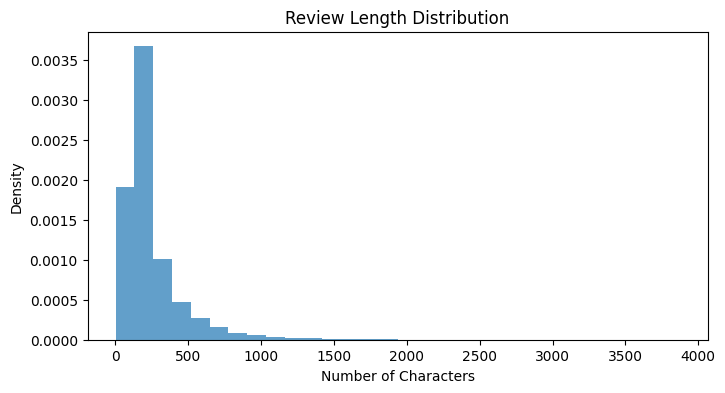

In [168]:
plt.figure(figsize=(8, 4))
plt.hist(df['review_length'], bins=30, density=True, alpha=0.7)
plt.title('Review Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Density')
plt.show()

In [169]:
print(df["Timestamp"].head(10))  # Print first 10 values

0                 NaN
1     Mar 2025•family
2    Dec 2024•couples
3     Dec 2024•family
4     Jul 2024•family
5     Jun 2024•family
6    Sep 2024•couples
7    Nov 2023•couples
8       Sep 2023•solo
9    Apr 2024•couples
Name: Timestamp, dtype: object


In [170]:
import re

# Ensure 'Timestamp' is a string and handle NaN values
df["Timestamp"] = df["Timestamp"].astype(str).replace(["nan", "NaN", "None"], "")

# Improved regex to capture all months, including abbreviations like "févr."
df["Timestamp"] = df["Timestamp"].apply(lambda x: re.search(r'([a-zA-ZéûîôàçêûÉÛÎÔÀÇÊ]+)\.?\s*(\d{4})', x).group(0) if re.search(r'([a-zA-ZéûîôàçêûÉÛÎÔÀÇÊ]+)\.?\s*(\d{4})', x) else pd.NA)

# Display cleaned timestamps
print(df["Timestamp"].head(10))


0        <NA>
1    Mar 2025
2    Dec 2024
3    Dec 2024
4    Jul 2024
5    Jun 2024
6    Sep 2024
7    Nov 2023
8    Sep 2023
9    Apr 2024
Name: Timestamp, dtype: object


In [171]:
df["Timestamp"] = df["Timestamp"].astype(str).str.lower().str.strip()
print(df["Timestamp"].unique()[:20])  # Show 20 unique values
df["Timestamp"].value_counts()

['<na>' 'mar 2025' 'dec 2024' 'jul 2024' 'jun 2024' 'sep 2024' 'nov 2023'
 'sep 2023' 'apr 2024' 'aug 2023' 'oct 2023' 'jul 2023' 'oct 2024'
 'feb 2025' 'jan 2025' 'nov 2024' 'may 2024' 'jan 2024' 'apr 2023'
 'feb 2024']


,count
Timestamp,
<na>,1190
oct 2024,850
dec 2024,830
sep 2024,813
jan 2025,808
...,...
jun 2012,1
nov 2011,1
dec 2013,1


In [172]:
print(df["month_year"].unique()[:20])  # Show 20 unique values

[nan 'WrittenMarch 2, 2025' 'WrittenJanuary 8, 2025'
 'WrittenDecember 15, 2024' 'WrittenJuly 6, 2024' 'WrittenJune 2, 2024'
 'WrittenSeptember 28, 2024' 'WrittenNovember 17, 2023'
 'WrittenOctober 3, 2023' 'WrittenApril 5, 2024' 'WrittenAugust 14, 2023'
 'WrittenOctober 13, 2023' 'WrittenOctober 4, 2023'
 'WrittenDecember 13, 2024' 'WrittenApril 29, 2024'
 'WrittenOctober 24, 2023' 'WrittenSeptember 10, 2023'
 'WrittenNovember 8, 2023' 'WrittenNovember 27, 2023'
 'WrittenDecember 21, 2024']


In [173]:
df["month_year"] = df["month_year"].str.replace(r"^Written\s*", "", regex=True)

print(df["month_year"].unique()[:20])

[nan 'March 2, 2025' 'January 8, 2025' 'December 15, 2024' 'July 6, 2024'
 'June 2, 2024' 'September 28, 2024' 'November 17, 2023' 'October 3, 2023'
 'April 5, 2024' 'August 14, 2023' 'October 13, 2023' 'October 4, 2023'
 'December 13, 2024' 'April 29, 2024' 'October 24, 2023'
 'September 10, 2023' 'November 8, 2023' 'November 27, 2023'
 'December 21, 2024']


In [174]:
from datetime import datetime

# Convert 'month_year' to string and handle NaN values
df["month_year"] = df["month_year"].astype(str).replace("nan", "").str.strip()

# Convert 'Month Day, Year' format to 'YYYY-MM-DD'
def convert_date_format(date_str):
    if date_str:  # Ensure it's not an empty string
        try:
            return datetime.strptime(date_str, "%B %d, %Y").strftime("%Y-%m-%d")
        except ValueError:
            return pd.NA  # Return NA if the format doesn't match
    return pd.NA

# Apply the conversion function
df["month_year"] = df["month_year"].apply(convert_date_format)

# Display cleaned date column
print(df["month_year"].head(10))

0          <NA>
1    2025-03-02
2    2025-01-08
3    2024-12-15
4    2024-07-06
5    2024-06-02
6    2024-09-28
7    2023-11-17
8    2023-10-03
9    2024-04-05
Name: month_year, dtype: object


In [175]:
# We will delete the timestamp column, as it has more missing values (NA) than the month_year column.
# We also rename the month_year column with "Date"

df = df.drop('Timestamp', axis=1, errors='ignore')
df['month_year'] = df['month_year'].rename('Date')
df.head(5)

,restaurant_link,cust_name,contribution,rating,review_title,cust_type,review_body,month_year,review_length
0,https://www.tripadvisor.com/Restaurant_Review-...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,3
1,https://www.tripadvisor.com/Restaurant_Review-...,claudeb396,Preaux423contributions,5.0 of 5 bubbles,You will regret if you go without eating,family,"I make a pasted copy of all positive reviews,\...",2025-03-02,278
2,https://www.tripadvisor.com/Restaurant_Review-...,Alain M,Paris450contributions,5.0 of 5 bubbles,Very valuable set,couples,Excellent value for money from lunch menu on w...,2025-01-08,601
3,https://www.tripadvisor.com/Restaurant_Review-...,Fearless536621,6contributions,5.0 of 5 bubbles,A Memorable Evening,family,"Excellent experience, dinner offered many opti...",2024-12-15,584
4,https://www.tripadvisor.com/Restaurant_Review-...,Papillondechant,67contributions,5.0 of 5 bubbles,Amazing quality French food with friendly neig...,family,This was by far our best meal in Paris. We wer...,2024-07-06,957


In [176]:
df['rating'].value_counts()

,count
rating,
5.0 of 5 bubbles,17320
4.0 of 5 bubbles,1311
3.0 of 5 bubbles,317
2.0 of 5 bubbles,126
1.0 of 5 bubbles,116


In [177]:
import re

# Extract only the numeric rating from the "rating" column
df["rating"] = df["rating"].astype(str).apply(lambda x: re.search(r'(\d+),?0?', x).group(1) if re.search(r'(\d+),?0?', x) else pd.NA)

# Convert the extracted values to integers
df["rating"] = pd.to_numeric(df["rating"], errors='coerce')

# Display transformed ratings
df["rating"].value_counts()

,count
rating,
5.0,17320
4.0,1311
3.0,317
2.0,126
1.0,116


In [178]:
df.head()

,restaurant_link,cust_name,contribution,rating,review_title,cust_type,review_body,month_year,review_length
0,https://www.tripadvisor.com/Restaurant_Review-...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,3
1,https://www.tripadvisor.com/Restaurant_Review-...,claudeb396,Preaux423contributions,5.0,You will regret if you go without eating,family,"I make a pasted copy of all positive reviews,\...",2025-03-02,278
2,https://www.tripadvisor.com/Restaurant_Review-...,Alain M,Paris450contributions,5.0,Very valuable set,couples,Excellent value for money from lunch menu on w...,2025-01-08,601
3,https://www.tripadvisor.com/Restaurant_Review-...,Fearless536621,6contributions,5.0,A Memorable Evening,family,"Excellent experience, dinner offered many opti...",2024-12-15,584
4,https://www.tripadvisor.com/Restaurant_Review-...,Papillondechant,67contributions,5.0,Amazing quality French food with friendly neig...,family,This was by far our best meal in Paris. We wer...,2024-07-06,957


In [179]:
# Function to extract restaurant name from URL
def extract_restaurant_name(url):
    match = re.search(r'Reviews-([^-]+)-', url)  # Extracts the part after "Reviews-" and before the next "-"
    if match:
        return match.group(1).replace("_", " ")  # Replace underscores with spaces for readability
    return "Unknown"

# Apply the function and overwrite the 'restaurant_link' column
df["restaurant_link"] = df["restaurant_link"].apply(extract_restaurant_name)

# Rename column to 'restaurant_name' for clarity
df.rename(columns={"restaurant_link": "restaurant_name"}, inplace=True)

# Display results
print(df["restaurant_name"].unique())


['Bistro Chez Pradel' 'Pastamore' 'Indian Villa' 'Petit Nuage Paris'
 'Boutary Restaurant' 'Il Etait Un Square' 'Supermian'
 'Restaurant Al Assil' 'Pizzeria Arrivederci' 'Petit Boutary' 'Da Franco'
 'Nell Arte' 'The Frog and Princess' 'Pizzamore Paris' 'Da Giuseppe'
 'La Baraque' 'Assanabel Saint Germain' 'Pizza du Chef' 'Chez Nicos'
 'Peppe Pizzeria Boulogne' 'Les Apotres de Pigalle' 'Le Comptoir Boutary'
 'Nirvana Inde' 'Assanabel Republic Marsh' 'L Angelus Du Canal'
 'Bistrot L olivier' 'Nectar' 'Bagel Way' 'Bistrot Kinzo'
 'Bistrot Instinct' 'Gusto Italia 218' 'Oriental Bowl Bar a Couscous'
 'Le Maxan Restaurant' 'Mian Fan Montparnasse' 'Habile' 'Pizza Presto'
 'Aspic' 'Akabeko Restaurant' 'Madito' 'Zincou Vins Tapas'
 'La Chaise Haute' 'Via Emilia' 'Neonato' 'Comptoir Gourmet' 'Le Bayadere'
 'B Better' 'Bus Toque' 'L Atelier Ramey' 'Poni' 'Vale Ale'
 'Mian Fan Dumpling Factory']


In [180]:
# Find the most most popular restaurants based on review count and average rating

# Group by restaurant name, count reviews, and calculate average rating
restaurant_stats = df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Sort by review count and then average rating
restaurant_stats = restaurant_stats.sort_values(by=['count', 'mean'], ascending=False)

# Display the top restaurants
print(restaurant_stats.head(10)) # Display top 10, adjust as needed


                          count      mean
restaurant_name                          
Pizzeria Arrivederci       3129  4.919143
Pastamore                  1584  4.839646
Il Etait Un Square         1171  4.848847
Pizzamore Paris            1106  4.873418
Boutary Restaurant         1081  4.854764
Les Apotres de Pigalle     1046  4.859465
Assanabel Republic Marsh    627  4.835726
Bus Toque                   609  4.768473
Aspic                       559  4.874776
Nectar                      555  4.911712


In [181]:
df["number_of_contributions"] = df["contribution"].astype(str).apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else pd.NA)

# Convert to integer
df["number_of_contributions"] = pd.to_numeric(df["number_of_contributions"], errors='coerce')

# Drop the old 'contribution' column
df.drop(columns=["contribution"], inplace=True)

In [182]:
df

,restaurant_name,cust_name,rating,review_title,cust_type,review_body,month_year,review_length,number_of_contributions
0,Bistro Chez Pradel,NaN,NaN,NaN,NaN,NaN,<NA>,3,NaN
1,Bistro Chez Pradel,claudeb396,5.0,You will regret if you go without eating,family,"I make a pasted copy of all positive reviews,\...",2025-03-02,278,423.0
2,Bistro Chez Pradel,Alain M,5.0,Very valuable set,couples,Excellent value for money from lunch menu on w...,2025-01-08,601,450.0
3,Bistro Chez Pradel,Fearless536621,5.0,A Memorable Evening,family,"Excellent experience, dinner offered many opti...",2024-12-15,584,6.0
4,Bistro Chez Pradel,Papillondechant,5.0,Amazing quality French food with friendly neig...,family,This was by far our best meal in Paris. We wer...,2024-07-06,957,67.0
...,...,...,...,...,...,...,...,...,...
20290,Nirvana Inde,Jeremy F,5.0,Excellent food,family,My family of 6 had dinner recently and we were...,2018-02-19,289,14.0
20291,Nirvana Inde,Milena S,5.0,Very good,none,The place is amazing and the atmosphere is ple...,2018-02-12,254,1.0
20292,Nirvana Inde,JCG1995,4.0,Excellent Indian Food,couples,Me and my partner were craving for some Indian...,2018-01-24,769,46.0
20293,Nirvana Inde,Liany,5.0,"Great indian restaurant, excellent food",business,"we were there for a business dinner, everythin...",2017-12-05,198,346.0


In [183]:
# 1. Remove rows where 'url' is populated but 'cust_name' is null
df = df.dropna(subset=['cust_name'], how='any')

# 2. Remove "Read more" substring from 'review_body'
df['review_body'] = df['review_body'].str.replace('Read more', '', regex=False)


<ipython-input-183-aced1dee368c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_body'] = df['review_body'].str.replace('Read more', '', regex=False)


### Text Mining

In [184]:
# Create tokens column and get number of tokens
df['tokens'] = df['review_body'].apply(lambda x: str(x).split())
df['num_tokens'] = df['tokens'].map(len)

# Drop the tokens column since we'll create a better tokenized version later
df.drop(columns=['tokens'], inplace=True)


<ipython-input-184-4e3db09fd336>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokens'] = df['review_body'].apply(lambda x: str(x).split())
<ipython-input-184-4e3db09fd336>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_tokens'] = df['tokens'].map(len)
<ipython-input-184-4e3db09fd336>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

In [185]:
pip install textacy

In [186]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 62.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [187]:
!pip install unidecode

In [188]:
import textacy
from unidecode import unidecode  # Import unidecode for non-ASCII character handling


def clean_text(text):
    """
    Clean the given text by lowercasing, removing URLs, non-ASCII characters, etc.

    Parameters:
    - text (str): The text to clean.

    Returns:
    - str: The cleaned text.
    """
    # Check if text is a string before applying lower()
    if isinstance(text, str):
        text = text.lower()  # Lowercase the text
        text = re.sub(r'http\S+', '', text, flags=re.MULTILINE)  # Remove URLs
        text = re.sub(r"[^\s\d]+\.[^\s\d]+", "", text)  # Remove URLs
        text = text.replace('\n', ' ').replace('\r', '')  # Remove newlines and carriage returns
        text = re.sub(r"[^\w\d'\s]+", '', text)  # Remove punctuation and symbols
        text = ' '.join(x for x in text.split() if not x.startswith('@'))  # Remove @ mentions
        text = unidecode(text)  # Replace non-ASCII characters with ASCII equivalents
        text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    # If text is not a string (e.g., NaN), return an empty string
    else:
        text = '' # Handle NaN or non-string values by returning an empty string
    return text

# Apply the clean_text function to the 'review_body' column
df['review_body'] = df['review_body'].apply(clean_text)
df['review_title'] = df['review_title'].apply(clean_text)

<ipython-input-188-3c2d6e0af33d>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_body'] = df['review_body'].apply(clean_text)
<ipython-input-188-3c2d6e0af33d>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_title'] = df['review_title'].apply(clean_text)


In [189]:
df['review_body'][22]

'one of my favorite restaurants in paris at pradel you will feel at the welcome is warm lots of attention to each customer the products are fresh the meats are perfectly cooked according to request and the dishes are delicious the setting is typical of parisian brasseries but without frills and frills you can go there with your eyes closed you will never be disappointed'

In [190]:
import spacy
from nltk.tokenize import TweetTokenizer
from spacy.lang.en.stop_words import STOP_WORDS

In [191]:
tokenizer = TweetTokenizer()

df['tokens_tweet'] = df['review_body'].apply(lambda x: tokenizer.tokenize(str(x)) if pd.notnull(x) else [])
df['tokens_title'] = df['review_title'].apply(lambda x: tokenizer.tokenize(str(x)) if pd.notnull(x) else [])
df['sentiment'] = df['rating'].apply(lambda x: 'Positive' if x >= 2.5 else 'Negative')


<ipython-input-191-af76ca12115b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokens_tweet'] = df['review_body'].apply(lambda x: tokenizer.tokenize(str(x)) if pd.notnull(x) else [])
<ipython-input-191-af76ca12115b>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokens_title'] = df['review_title'].apply(lambda x: tokenizer.tokenize(str(x)) if pd.notnull(x) else [])
<ipython-input-191-af76ca12115b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [192]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords_and_short_tokens(tokens):
    """
    Removes stopwords, single-character tokens, and numbers from a list of tokens.

    Parameters:
    - tokens (list): A list of tokens.

    Returns:
    - list: A list of tokens without stopwords, single-character tokens, and numbers.
    """
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 1 and not word.isdigit()
    ]
    return filtered_tokens

df['tokens_tweet'] = df['tokens_tweet'].apply(remove_stopwords_and_short_tokens)
df['tokens_title'] = df['tokens_title'].apply(remove_stopwords_and_short_tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
<ipython-input-192-b13d88a488fe>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokens_tweet'] = df['tokens_tweet'].apply(remove_stopwords_and_short_tokens)
<ipython-input-192-b13d88a488fe>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokens_title'] = df['tokens_title'].apply(remove_stopwords_and_short_tokens)


In [193]:
# print the most popular tokens in the column

from collections import Counter

def get_top_n_words(corpus, n=None):
    vec = Counter()
    for text in corpus:
        vec.update(text)
    return vec.most_common(n)

top_words = get_top_n_words(df['tokens_tweet'], n=20)
top_words


[('food', 8068),
 ('good', 8019),
 ('service', 7326),
 ('great', 6464),
 ('restaurant', 5756),
 ('paris', 4789),
 ('recommend', 4635),
 ('excellent', 4577),
 ('friendly', 4570),
 ('staff', 4567),
 ('place', 4461),
 ('delicious', 4270),
 ('nice', 3623),
 ('pizza', 3193),
 ('us', 2817),
 ('best', 2762),
 ('really', 2740),
 ('menu', 2693),
 ('dishes', 2672),
 ('experience', 2671)]

### Sentiment Analysis

In [194]:
!pip install selenium
!pip install jyquickhelper
!apt-get update
!apt-get install -y google-chrome-stable
!pip install --upgrade selenium

!pip install webdriver_manager

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 257 kB in 1s (177 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package list

In [195]:
pip install nltk

In [196]:
#On importe les modules nécessaires de Selenium
from selenium import webdriver
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
import time
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
import jyquickhelper

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [197]:
!pip install wordcloud

In [198]:
# si besoin est faire l'install : pip install wordcloud
from wordcloud import WordCloud
from wordcloud import STOPWORDS
import matplotlib.pyplot as plt

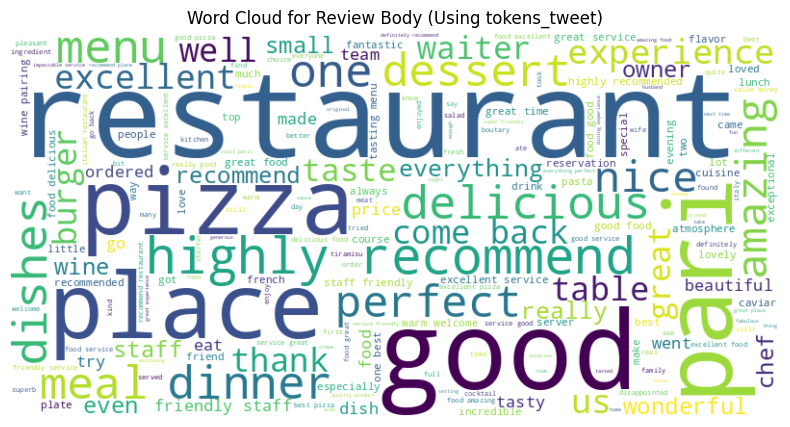

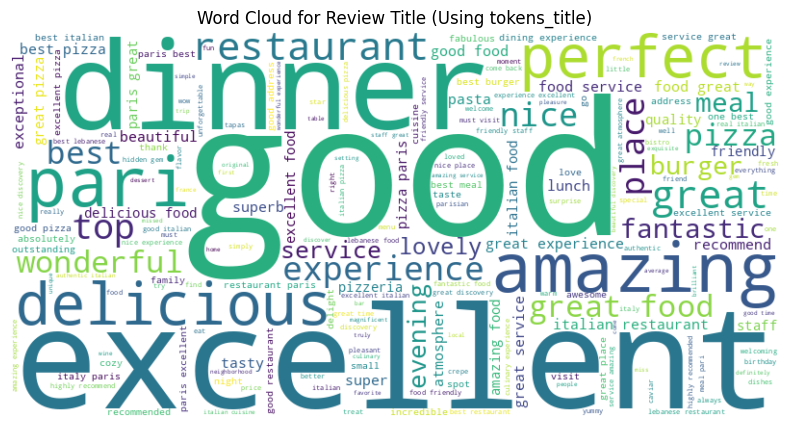

In [199]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to create text from tokens for WordCloud
def create_text_from_tokens(token_series):
    all_tokens = []
    for tokens in token_series:
        if isinstance(tokens, list):  # Check if it's a list of tokens
            all_tokens.extend(tokens)  # Add tokens to the list
    return ' '.join(all_tokens)  # Join tokens into a single string

# Generate word cloud for 'tokens_tweet'
text_review_body = create_text_from_tokens(df['tokens_tweet'])
wordcloud_review_body = WordCloud(background_color="white", width=800, height=400).generate(text_review_body)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_review_body, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Review Body (Using tokens_tweet)")
plt.show()

# Generate word cloud for 'tokens_title'
text_review_title = create_text_from_tokens(df['tokens_title'])
wordcloud_review_title = WordCloud(background_color="white", width=800, height=400).generate(text_review_title)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_review_title, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Review Title (Using tokens_title)")
plt.show()

In [200]:
from collections import Counter

# 1. Combine all tokens from 'tokens_tweet' into a single list
all_tokens = []
for tokens_list in df['tokens_tweet']:
    all_tokens.extend(tokens_list)

# 2. Calculate token frequencies using Counter
token_counts = Counter(all_tokens)

# 3. Calculate and print the percentage for each token
total_tokens = sum(token_counts.values())  # Total number of tokens
for token, frequency in token_counts.items():
    percentage = (frequency / total_tokens) * 100
    print(f"{token}: {percentage:.5f}%")

make: 0.17409%
pasted: 0.00045%
copy: 0.00045%
positive: 0.01952%
reviews: 0.14022%
provincial: 0.00022%
eat: 0.21694%
sunday: 0.01436%
home: 0.10971%
cooking: 0.03949%
warm: 0.39171%
welcome: 0.49872%
value: 0.13954%
money: 0.09759%
common: 0.00337%
consult: 0.00022%
priori: 0.00045%
new: 0.06730%
cream: 0.04689%
brulee: 0.00269%
salted: 0.00314%
butter: 0.01391%
tell: 0.02984%
news: 0.00202%
see: 0.11240%
later: 0.02423%
excellent: 1.02684%
lunch: 0.16647%
menu: 0.60417%
weekdays: 0.00090%
caricaturing: 0.00022%
could: 0.14403%
say: 0.11756%
exceptional: 0.14627%
located: 0.03814%
high: 0.12855%
quality: 0.47270%
tourist: 0.01929%
area: 0.08570%
place: 1.00081%
des: 0.00516%
vosges: 0.00022%
carnivalet: 0.00022%
museum: 0.00179%
boon: 0.00022%
startermain: 0.00157%
coursedessert: 0.00179%
less: 0.02490%
euros: 0.04487%
good: 1.79904%
fresh: 0.27258%
simple: 0.07314%
well: 0.55840%
cooked: 0.10208%
products: 0.15704%
efficient: 0.07426%
service: 1.64357%
conclusion: 0.00471%
plan: 0.0

In [201]:
# **Summary:**
# This code block calculates the relative term frequency (TF) for each token
# found in the 'tokens_tweet' column of the DataFrame. It first collects all
# tokens into a single list, then uses the Counter object to get the frequency
# of each token. Finally, it calculates the relative TF for each token by
# dividing its frequency by the total number of tokens and stores the results
# in a dictionary called 'tfdict'. This dictionary can be used for tasks like
# identifying important keywords or topics in the text data.
from collections import Counter

# 1. Combine all tokens from 'tokens_tweet' into a single list
all_tokens = []
for tokens_list in df['tokens_tweet']:
    all_tokens.extend(tokens_list)

# 2. Calculate token frequencies using Counter
token_counts = Counter(all_tokens)

# 3. Create the tfdict dictionary
tfdict = {}
total_tokens = sum(token_counts.values())  # Total number of tokens
for token, frequency in token_counts.items():
    relative_tf = frequency / total_tokens
    tfdict[token] = relative_tf

# 4. Display the tfdict dictionary (optional)
print(tfdict)

{'make': 0.00174093301446141, 'pasted': 4.48694075892116e-06, 'copy': 4.48694075892116e-06, 'positive': 0.00019518192301307046, 'reviews': 0.0014021689871628624, 'provincial': 2.24347037946058e-06, 'eat': 0.002169435856938381, 'sunday': 0.00014358210428547713, 'home': 0.0010970570155562237, 'cooking': 0.0003948507867850621, 'warm': 0.003917099282538173, 'welcome': 0.004987234653540869, 'value': 0.0013954385760244806, 'money': 0.0009759096150653523, 'common': 3.36520556919087e-05, 'consult': 2.24347037946058e-06, 'priori': 4.48694075892116e-06, 'new': 0.000673041113838174, 'cream': 0.0004688853093072612, 'brulee': 2.692164455352696e-05, 'salted': 3.140858531244812e-05, 'butter': 0.00013909516352655595, 'tell': 0.00029838156046825716, 'news': 2.019123341514522e-05, 'see': 0.0011239786601097506, 'later': 0.00024229480098174265, 'excellent': 0.010268363926791075, 'lunch': 0.0016646550215597504, 'menu': 0.006041665731887342, 'weekdays': 8.97388151784232e-06, 'caricaturing': 2.24347037946058

In [202]:
import sys
!{sys.executable} -m pip install textblob

In [203]:
import textblob
from textblob import TextBlob

<ipython-input-204-2396167a546f>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_body_text'] = df['tokens_tweet'].apply(join_tokens)
<ipython-input-204-2396167a546f>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_title_text'] = df['tokens_title'].apply(join_tokens)
<ipython-input-204-2396167a546f>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentatio

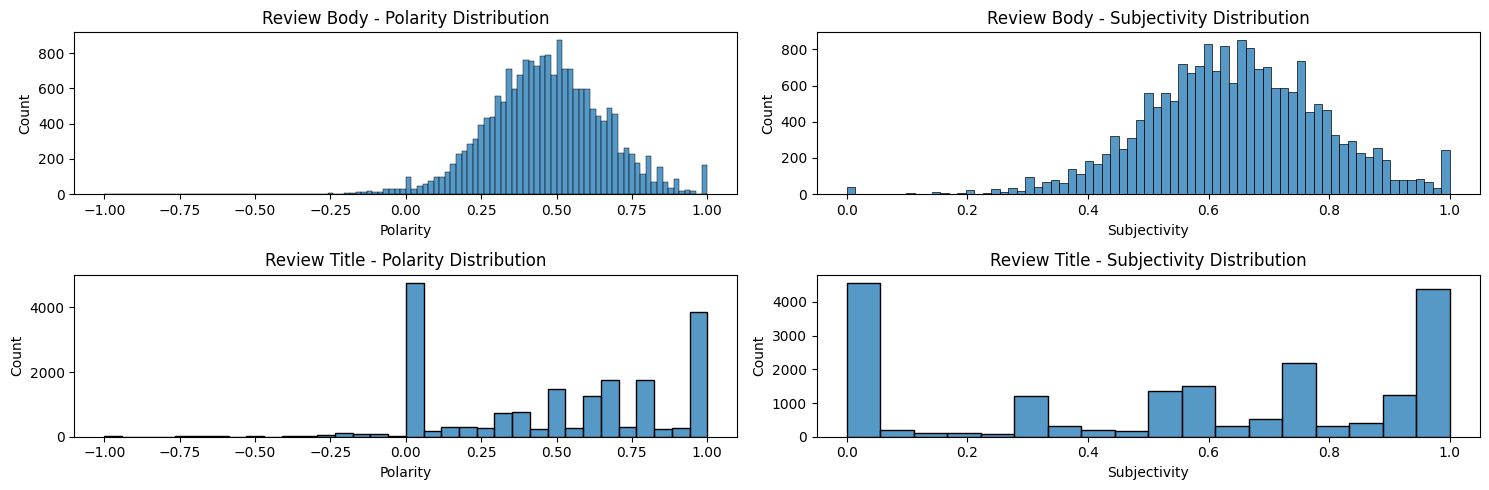


Top 20 Most Common Words in Review Body and their Sentiment Scores:
Word: food, Polarity: 0.000, Subjectivity: 0.000
Word: good, Polarity: 0.700, Subjectivity: 0.600
Word: service, Polarity: 0.000, Subjectivity: 0.000
Word: great, Polarity: 0.800, Subjectivity: 0.750
Word: restaurant, Polarity: 0.000, Subjectivity: 0.000
Word: paris, Polarity: 0.000, Subjectivity: 0.000
Word: recommend, Polarity: 0.000, Subjectivity: 0.000
Word: excellent, Polarity: 1.000, Subjectivity: 1.000
Word: friendly, Polarity: 0.375, Subjectivity: 0.500
Word: staff, Polarity: 0.000, Subjectivity: 0.000
Word: place, Polarity: 0.000, Subjectivity: 0.000
Word: delicious, Polarity: 1.000, Subjectivity: 1.000
Word: nice, Polarity: 0.600, Subjectivity: 1.000
Word: pizza, Polarity: 0.000, Subjectivity: 0.000
Word: us, Polarity: 0.000, Subjectivity: 0.000
Word: best, Polarity: 1.000, Subjectivity: 0.300
Word: really, Polarity: 0.200, Subjectivity: 0.200
Word: menu, Polarity: 0.000, Subjectivity: 0.000
Word: dishes, Po

In [204]:

# Function to join tokens back into a string
def join_tokens(tokens):
    return " ".join(tokens)

# Apply the function to create text from tokens
df['review_body_text'] = df['tokens_tweet'].apply(join_tokens)
df['review_title_text'] = df['tokens_title'].apply(join_tokens)

# Perform sentiment analysis using the joined text
df['body_sentiment'] = df['review_body_text'].apply(lambda x: TextBlob(str(x)).sentiment)
df['title_sentiment'] = df['review_title_text'].apply(lambda x: TextBlob(str(x)).sentiment)

# Extract polarity and subjectivity scores (same as before)
df['body_polarity'] = df['body_sentiment'].apply(lambda x: x[0])
df['body_subjectivity'] = df['body_sentiment'].apply(lambda x: x[1])
df['title_polarity'] = df['title_sentiment'].apply(lambda x: x[0])
df['title_subjectivity'] = df['title_sentiment'].apply(lambda x: x[1])

# Create plots for sentiment distribution
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 5))

# Review Body Polarity Distribution
sns.histplot(data=df['body_polarity'], ax=ax1)
ax1.set_title('Review Body - Polarity Distribution')
ax1.set_xlabel('Polarity')

# Review Body Subjectivity Distribution
sns.histplot(data=df['body_subjectivity'], ax=ax2)
ax2.set_title('Review Body - Subjectivity Distribution')
ax2.set_xlabel('Subjectivity')

# Review Title Polarity Distribution
sns.histplot(data=df['title_polarity'], ax=ax3)
ax3.set_title('Review Title - Polarity Distribution')
ax3.set_xlabel('Polarity')

# Review Title Subjectivity Distribution
sns.histplot(data=df['title_subjectivity'], ax=ax4)
ax4.set_title('Review Title - Subjectivity Distribution')
ax4.set_xlabel('Subjectivity')

plt.tight_layout()
plt.show()

# Get most common words and their sentiment scores
def get_word_sentiments(token_series):
    word_sentiments = {}
    for tokens in token_series:  # Iterate over lists of tokens
        for word in tokens:
            if word.lower() not in word_sentiments:
                word_sentiments[word.lower()] = []
            word_sentiments[word.lower()].append(TextBlob(word).sentiment)  # Analyze sentiment of word

    # Calculate average sentiment for each word (same as before)
    word_avg_sentiments = {}
    for word, sentiments in word_sentiments.items():
        avg_polarity = sum(s[0] for s in sentiments) / len(sentiments)
        avg_subjectivity = sum(s[1] for s in sentiments) / len(sentiments)
        word_avg_sentiments[word] = (avg_polarity, avg_subjectivity)

    return word_avg_sentiments

# Get word sentiments for both review body and title (using tokenized columns)
body_word_sentiments = get_word_sentiments(df['tokens_tweet'])
title_word_sentiments = get_word_sentiments(df['tokens_title'])

# Get total term frequency (from tokens_tweet)
all_tokens = [token for tokens_list in df['tokens_tweet'] for token in tokens_list]
total_term_frequency = Counter(all_tokens)

# Print top 20 most common words and their sentiment scores
print("\nTop 20 Most Common Words in Review Body and their Sentiment Scores:")
for word, count in total_term_frequency.most_common(20):
    if word.lower() in body_word_sentiments:
        polarity, subjectivity = body_word_sentiments[word.lower()]
        print(f"Word: {word}, Polarity: {polarity:.3f}, Subjectivity: {subjectivity:.3f}")

# Get detailed sentiment assessments for a sample review (using tokens)
sample_review_tokens = df['tokens_tweet'].iloc[0]
sample_review_text = " ".join(sample_review_tokens)  # Reconstruct text
sample_blob = TextBlob(sample_review_text)
print("\nDetailed Sentiment Assessment for Sample Review:")
print(sample_blob.sentiment_assessments)


In [205]:
print("Review Body Sentiment Analysis:")
print(f"Average Polarity: {df['body_polarity'].mean():.3f}")
print(f"Average Subjectivity: {df['body_subjectivity'].mean():.3f}")
print("\nReview Title Sentiment Analysis:")
print(f"Average Polarity: {df['title_polarity'].mean():.3f}")
print(f"Average Subjectivity: {df['title_subjectivity'].mean():.3f}")

Review Body Sentiment Analysis:
Average Polarity: 0.465
Average Subjectivity: 0.642

Review Title Sentiment Analysis:
Average Polarity: 0.493
Average Subjectivity: 0.552


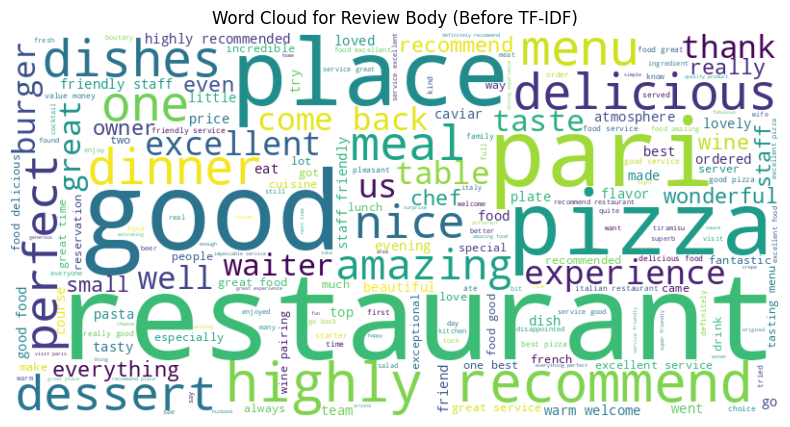

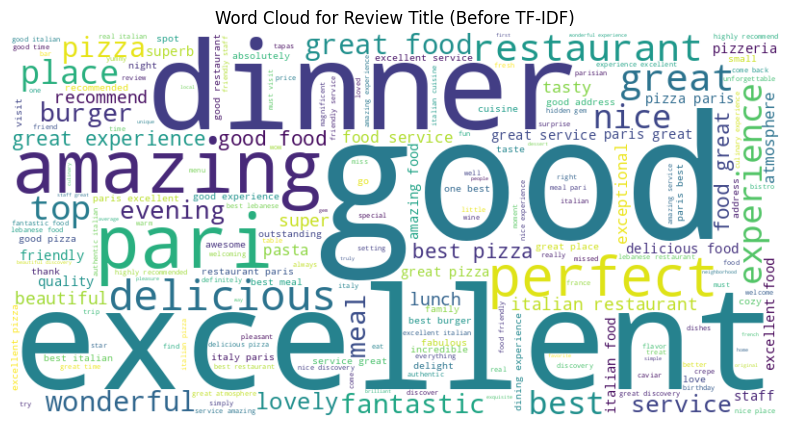

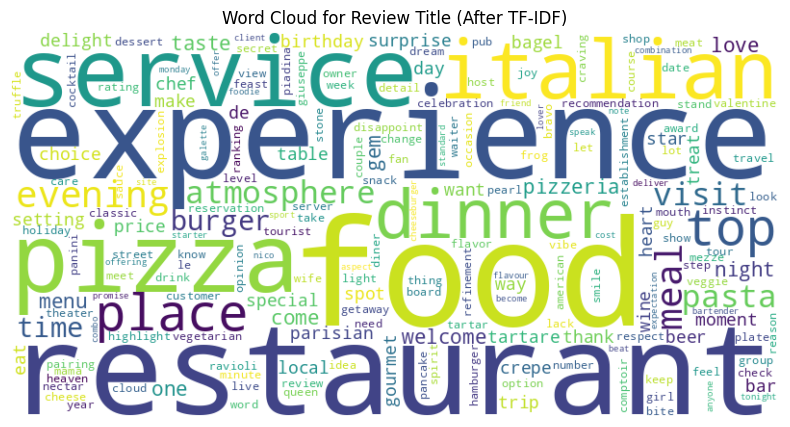

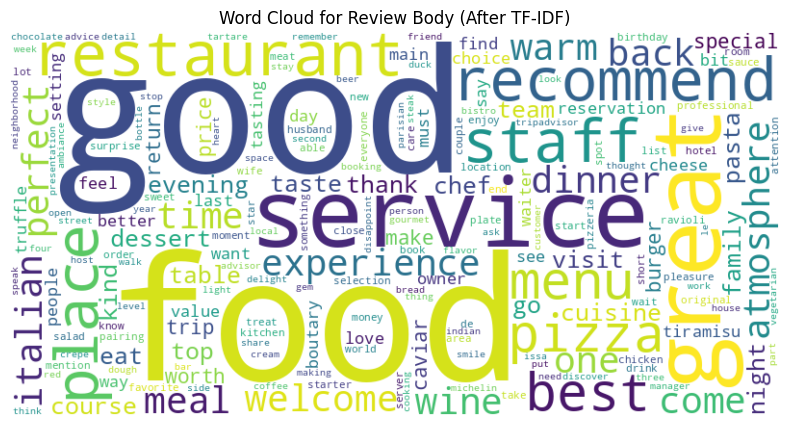

In [206]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Function to create text from tokens for WordCloud and TF-IDF
def create_text_from_tokens(token_series):
    all_tokens = []
    for tokens in token_series:
        if isinstance(tokens, list):  # Check if it's a list of tokens
            all_tokens.extend(tokens)  # Add tokens to the list
    return ' '.join(all_tokens)  # Join tokens into a single string

# Create separate TfidfVectorizer objects for title and body
vectorizer_title = TfidfVectorizer()  # For review title
vectorizer_body = TfidfVectorizer()  # For review body

# Prepare text from tokens for TF-IDF
text_review_title = create_text_from_tokens(df['tokens_title'])
text_review_body = create_text_from_tokens(df['tokens_tweet'])

# Fit and transform using the text from tokens
tfidf_title = vectorizer_title.fit_transform([text_review_title])
tfidf_body = vectorizer_body.fit_transform([text_review_body])

# --- Word Clouds Before TF-IDF ---
# Generate word cloud for 'tokens_tweet'
wordcloud_review_body_before = WordCloud(background_color="white", width=800, height=400).generate(text_review_body)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_review_body_before, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Review Body (Before TF-IDF)")
plt.show()

# Generate word cloud for 'tokens_title'
wordcloud_review_title_before = WordCloud(background_color="white", width=800, height=400).generate(text_review_title)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_review_title_before, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Review Title (Before TF-IDF)")
plt.show()
# --- End of Word Clouds Before TF-IDF ---


# Convert TF-IDF matrix to a DataFrame for easier manipulation
tfidf_df_title = pd.DataFrame(tfidf_title.toarray(), columns=vectorizer_title.get_feature_names_out())
tfidf_df_body = pd.DataFrame(tfidf_body.toarray(), columns=vectorizer_body.get_feature_names_out())

# Function to create word cloud from TF-IDF DataFrame (modified for single row)
def create_wordcloud_from_tfidf(tfidf_df):
    word_freq = tfidf_df.iloc[0].sort_values(ascending=False)  # Get frequencies from the first row
    wordcloud_text = " ".join([word + " " * int(freq * 100) for word, freq in word_freq.items()])
    wordcloud = WordCloud(background_color="white", width=800, height=400).generate(wordcloud_text)
    return wordcloud

# --- Word Clouds After TF-IDF ---
# Create word clouds for review title after TF-IDF
wordcloud_review_title_after = create_wordcloud_from_tfidf(tfidf_df_title)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_review_title_after, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Review Title (After TF-IDF)")
plt.show()

# Create word clouds for review body after TF-IDF
wordcloud_review_body_after = create_wordcloud_from_tfidf(tfidf_df_body)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_review_body_after, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Review Body (After TF-IDF)")
plt.show()
# --- End of Word Clouds After TF-IDF ---

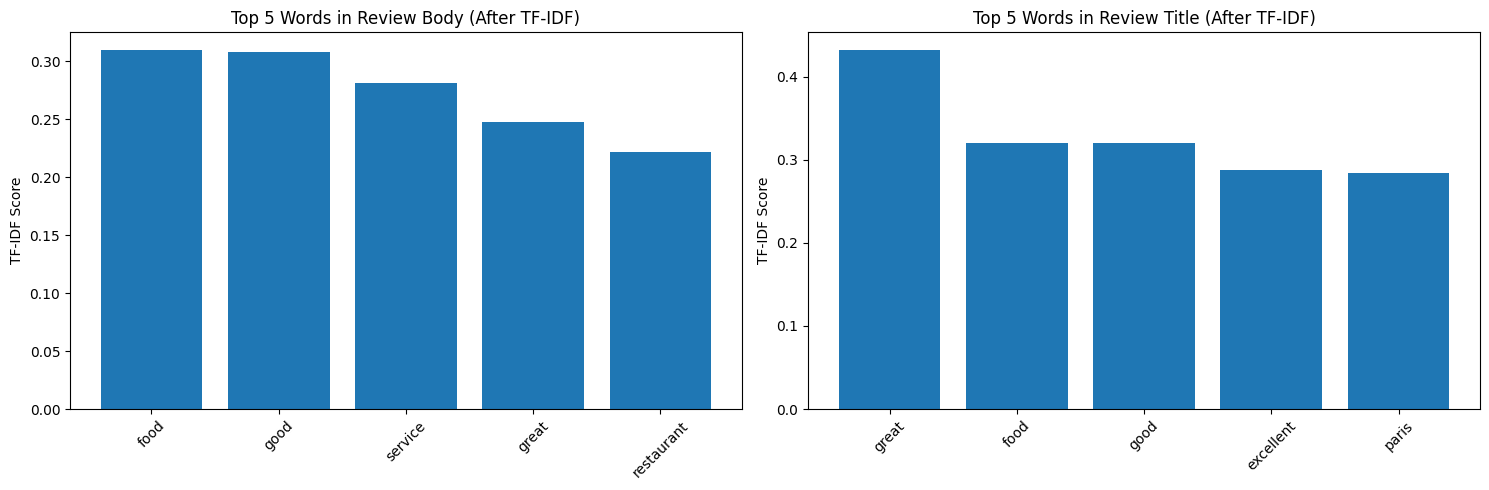

In [207]:
# Get top 5 words from TF-IDF for review body and title
top_5_body = tfidf_df_body.sum(axis=0).sort_values(ascending=False)[:5]
top_5_title = tfidf_df_title.sum(axis=0).sort_values(ascending=False)[:5]

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot for review body
ax1.bar(top_5_body.index, top_5_body.values)
ax1.set_title('Top 5 Words in Review Body (After TF-IDF)')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('TF-IDF Score')

# Plot for review title
ax2.bar(top_5_title.index, top_5_title.values)
ax2.set_title('Top 5 Words in Review Title (After TF-IDF)')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylabel('TF-IDF Score')

plt.tight_layout()
plt.show()


<ipython-input-208-a7b1fbdfcba9>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['body_bigrams'] = df['tokens_tweet'].apply(lambda x: get_ngrams_from_tokens(x, 2))
<ipython-input-208-a7b1fbdfcba9>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['body_trigrams'] = df['tokens_tweet'].apply(lambda x: get_ngrams_from_tokens(x, 3))
<ipython-input-208-a7b1fbdfcba9>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

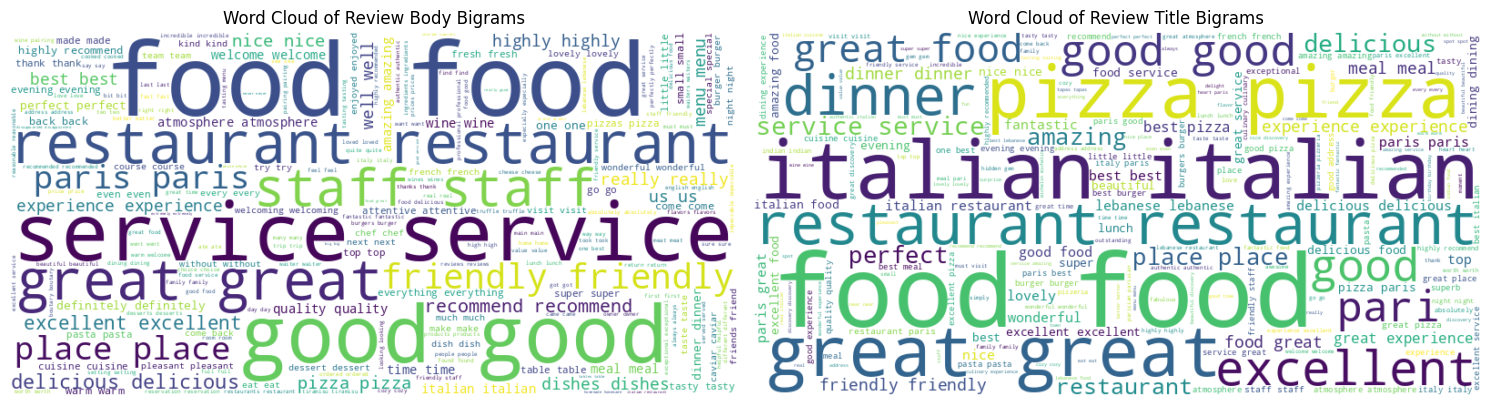

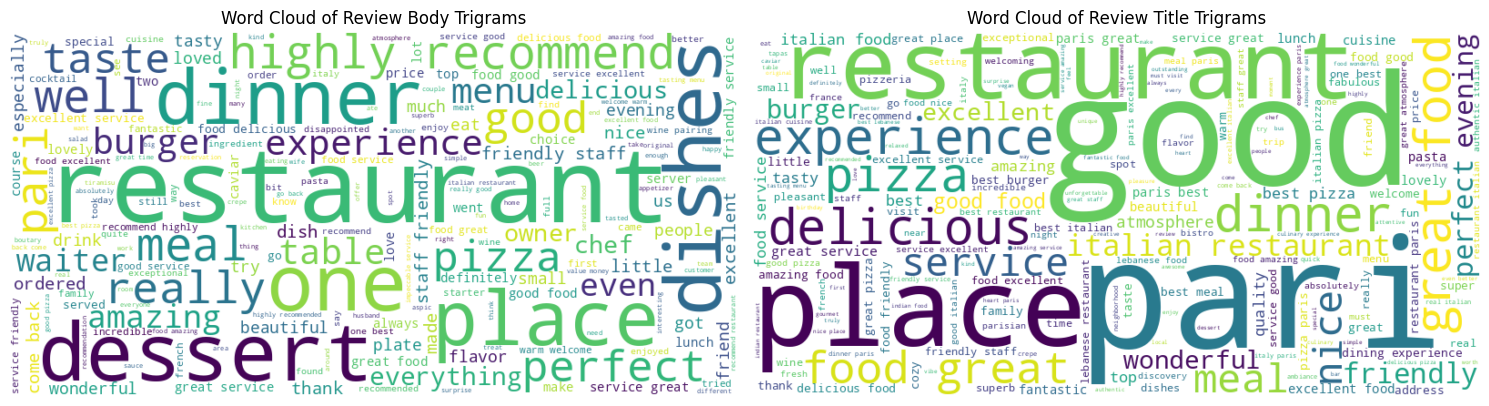

In [208]:
# Create bigrams and trigrams
from nltk import ngrams

# Function to create n-grams from tokens, excluding those with all same tokens
def get_ngrams_from_tokens(tokens, n):
    n_grams = list(ngrams(tokens, n))
    filtered_ngrams = [
        ' '.join(gram) for gram in n_grams
        if len(set(gram)) > 1  # Check if all tokens in the n-gram are unique
    ]
    return filtered_ngrams

# Create bigrams and trigrams for review body
df['body_bigrams'] = df['tokens_tweet'].apply(lambda x: get_ngrams_from_tokens(x, 2))
df['body_trigrams'] = df['tokens_tweet'].apply(lambda x: get_ngrams_from_tokens(x, 3))

# Create bigrams and trigrams for review title
df['title_bigrams'] = df['tokens_title'].apply(lambda x: get_ngrams_from_tokens(x, 2))
df['title_trigrams'] = df['tokens_title'].apply(lambda x: get_ngrams_from_tokens(x, 3))

# Function to create text from n-grams for wordcloud (modified)
def create_text_from_ngrams(series):
    all_ngrams = []
    for ngram_list in series:
        all_ngrams.extend(ngram_list)
    return ' '.join(all_ngrams)

# Create wordclouds for bigrams (using updated function)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(create_text_from_ngrams(df['body_bigrams']))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Body Bigrams')

plt.subplot(1, 2, 2)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(create_text_from_ngrams(df['title_bigrams']))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Title Bigrams')

plt.tight_layout()
plt.show()

# Create wordclouds for trigrams (using updated function)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(create_text_from_ngrams(df['body_trigrams']))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Body Trigrams')

plt.subplot(1, 2, 2)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(create_text_from_ngrams(df['title_trigrams']))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Title Trigrams')

plt.tight_layout()
plt.show()


Top 20 Positive Bigrams:
highly recommend: 1624
come back: 987
friendly staff: 662
highly recommended: 577
warm welcome: 544
staff friendly: 505
great service: 502
good food: 500
great food: 487
one best: 467
great time: 456
excellent service: 440
food delicious: 412
friendly service: 404
food good: 401
tasting menu: 397
food service: 395
delicious food: 390
would definitely: 388
really good: 371

Top 20 Negative Bigrams:
even though: 10
food good: 10
trip advisor: 10
nothing special: 10
main course: 10
great reviews: 8
italian restaurant: 7
good service: 7
told us: 7
michelin star: 7
much better: 7
served us: 6
thought would: 6
aperol spritz: 6
made reservation: 5
quality food: 5
service good: 5
main courses: 5
would recommend: 5
came back: 5

Top 20 Positive Trigrams:
definitely come back: 213
would highly recommend: 190
would definitely recommend: 178
good value money: 153
highly recommend restaurant: 151
next time paris: 118
made us feel: 111
food great service: 98
go eyes closed:

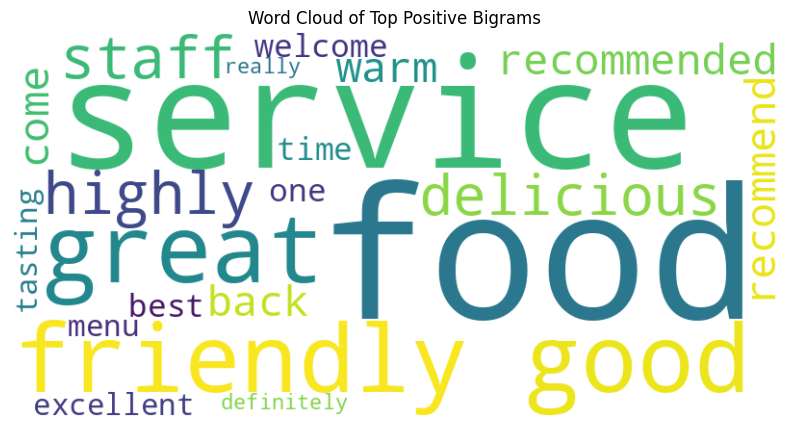

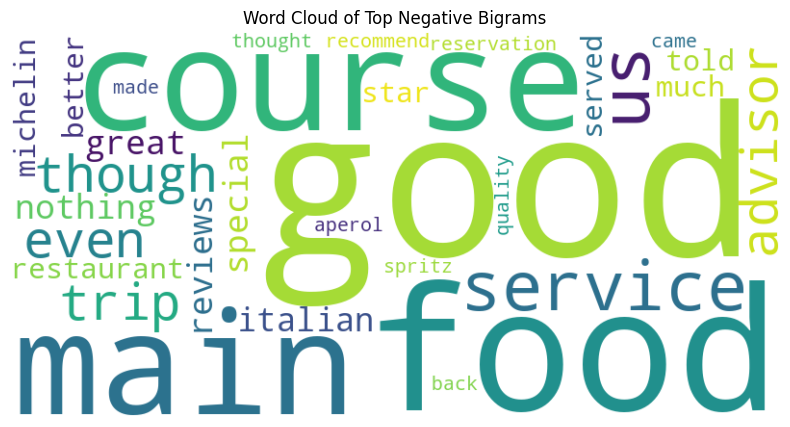

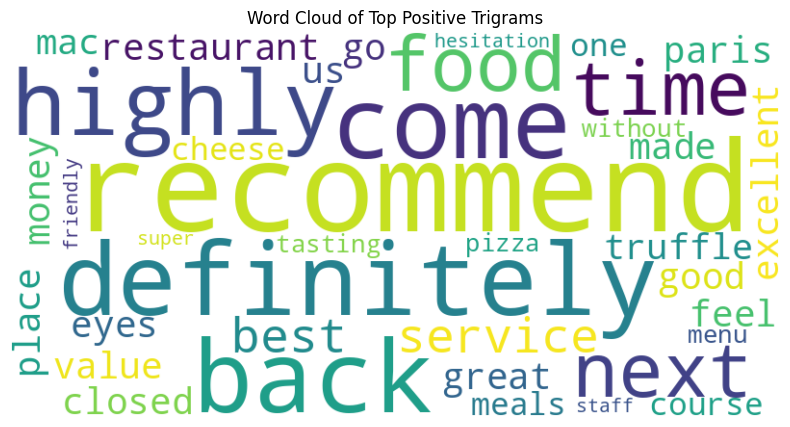

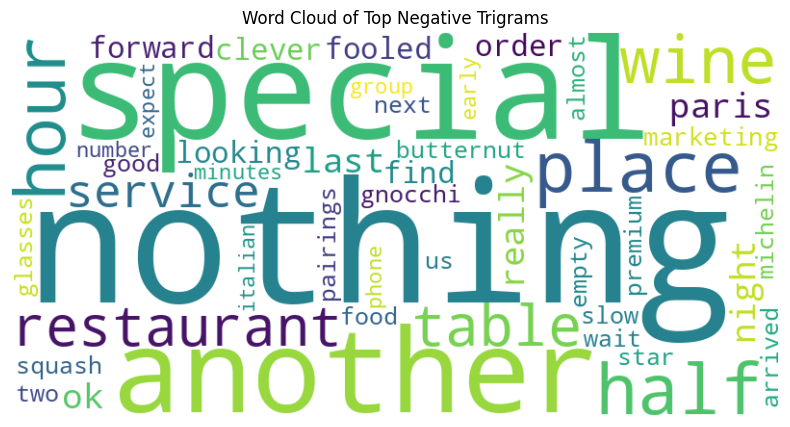

In [209]:
#What are the most common bigrams/trigrams in positive vs negative reviews?

from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Separate dataset into positive and negative reviews
positive_reviews = df[df['sentiment'] == 'Positive']
negative_reviews = df[df['sentiment'] == 'Negative']

# 2. Function to get top n-grams
def get_top_ngrams(corpus, n=None):
    vec = Counter()
    for text in corpus:
        if isinstance(text, list):  # Check if it's a list of bigrams/trigrams
            vec.update(text)  # Update the Counter with the ngrams
    return vec.most_common(n)

# 3. Analyze most frequent bigrams/trigrams for each sentiment
top_positive_bigrams = get_top_ngrams(positive_reviews['body_bigrams'], n=20)
top_negative_bigrams = get_top_ngrams(negative_reviews['body_bigrams'], n=20)

top_positive_trigrams = get_top_ngrams(positive_reviews['body_trigrams'], n=20)
top_negative_trigrams = get_top_ngrams(negative_reviews['body_trigrams'], n=20)

# 4. Print top bigrams/trigrams for each sentiment
print("\nTop 20 Positive Bigrams:")
for bigram, count in top_positive_bigrams:
    print(f"{bigram}: {count}")

print("\nTop 20 Negative Bigrams:")
for bigram, count in top_negative_bigrams:
    print(f"{bigram}: {count}")

print("\nTop 20 Positive Trigrams:")
for trigram, count in top_positive_trigrams:
    print(f"{trigram}: {count}")

print("\nTop 20 Negative Trigrams:")
for trigram, count in top_negative_trigrams:
    print(f"{trigram}: {count}")

# 5. Create Word Clouds for comparison (optional)
def create_wordcloud_from_ngrams(ngrams_list, title):
    ngram_text = ' '.join([ngram for ngram, count in ngrams_list])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ngram_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

create_wordcloud_from_ngrams(top_positive_bigrams, 'Word Cloud of Top Positive Bigrams')
create_wordcloud_from_ngrams(top_negative_bigrams, 'Word Cloud of Top Negative Bigrams')

create_wordcloud_from_ngrams(top_positive_trigrams, 'Word Cloud of Top Positive Trigrams')
create_wordcloud_from_ngrams(top_negative_trigrams, 'Word Cloud of Top Negative Trigrams')

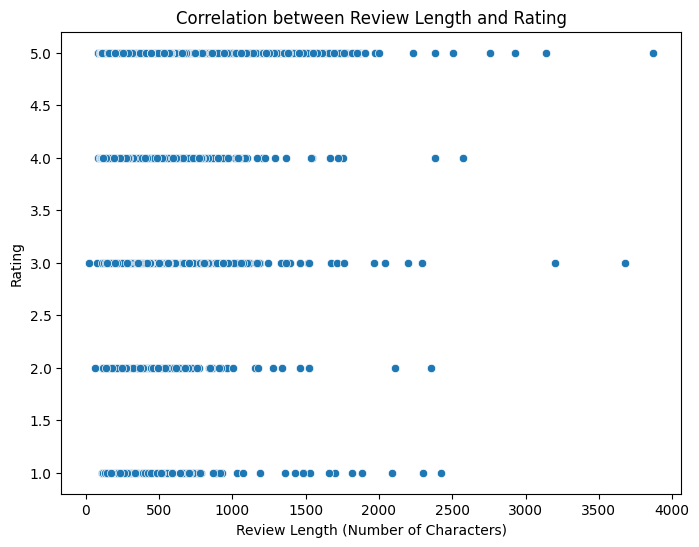

Pearson's correlation between review length and rating: -0.187
P-value: 0.000


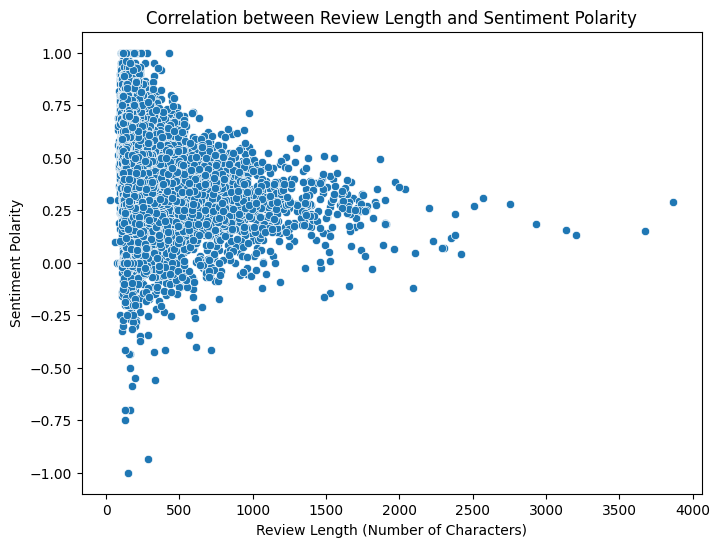

Pearson's correlation between review length and sentiment polarity: -0.330
P-value: 0.000


<ipython-input-210-dd3e14fe4aea>:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['length_category'] = pd.qcut(df['review_length'], 3, labels=['Short', 'Medium', 'Long'])
<ipython-input-210-dd3e14fe4aea>:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_sentiment_by_length = df.groupby('length_category')['body_polarity'].mean()
<ipython-input-210-dd3e14fe4aea>:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adop

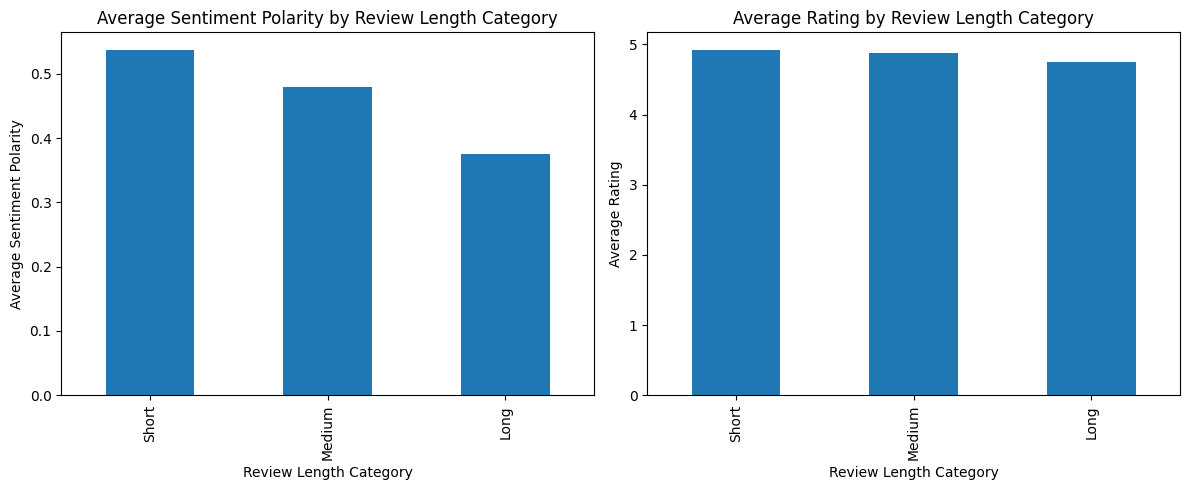

In [210]:
#Is there a correlation between review length and sentiment/rating?

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Correlation between Review Length and Rating
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='review_length', y='rating', data=df)
plt.title('Correlation between Review Length and Rating')
plt.xlabel('Review Length (Number of Characters)')
plt.ylabel('Rating')
plt.show()

# Calculate Pearson's correlation coefficient
correlation, p_value = stats.pearsonr(df['review_length'], df['rating'])
print(f"Pearson's correlation between review length and rating: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

# 2. Correlation between Review Length and Sentiment Polarity
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='review_length', y='body_polarity', data=df)  # Using body_polarity for sentiment
plt.title('Correlation between Review Length and Sentiment Polarity')
plt.xlabel('Review Length (Number of Characters)')
plt.ylabel('Sentiment Polarity')
plt.show()

# Calculate Pearson's correlation coefficient
correlation, p_value = stats.pearsonr(df['review_length'], df['body_polarity'])
print(f"Pearson's correlation between review length and sentiment polarity: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

# 3. Comparing Sentiment/Rating across Review Length Categories
# Create length categories (e.g., short, medium, long)
df['length_category'] = pd.qcut(df['review_length'], 3, labels=['Short', 'Medium', 'Long'])

# Calculate average sentiment/rating for each category
avg_sentiment_by_length = df.groupby('length_category')['body_polarity'].mean()
avg_rating_by_length = df.groupby('length_category')['rating'].mean()

# Create bar plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
avg_sentiment_by_length.plot(kind='bar')
plt.title('Average Sentiment Polarity by Review Length Category')
plt.xlabel('Review Length Category')
plt.ylabel('Average Sentiment Polarity')

plt.subplot(1, 2, 2)
avg_rating_by_length.plot(kind='bar')
plt.title('Average Rating by Review Length Category')
plt.xlabel('Review Length Category')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()


In [211]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.metrics.pairwise import cosine_similarity

# 1. Prepare data for vectorization
# Function to join tokens back into a string
def join_tokens(tokens):
    return " ".join(tokens)

# Apply the function to the 'tokens_tweet' column
df['review_body_tokens'] = df['tokens_tweet'].apply(join_tokens)

# 2. Vectorize the tokenized reviews using Bag-of-Words and TF-IDF
count_vect = CountVectorizer(stop_words='english')  # You might not need stop words removal here as you've already done it
X_bow = count_vect.fit_transform(df['review_body_tokens'])

tfidf_vect = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf_vect.fit_transform(df['review_body_tokens'])

# 3. Cosine Similarity (optional - using Bag-of-Words for demonstration)
similarity_matrix = cosine_similarity(X_bow[:10])  # Calculate for the first 10 reviews
print("Cosine similarity matrix (first 10 reviews):")
print(similarity_matrix)

# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment'])

# Train a Random Forest classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluate performance
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Positive')
recall = recall_score(y_test, y_pred, pos_label='Positive')

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)


<ipython-input-211-1479484de4aa>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_body_tokens'] = df['tokens_tweet'].apply(join_tokens)


Cosine similarity matrix (first 10 reviews):
[[1.         0.08528029 0.02540003 0.04417261 0.05345225 0.02886751
  0.08       0.15364426 0.         0.04364358]
 [0.08528029 1.         0.12184433 0.0588602  0.21367608 0.03077287
  0.36244122 0.02729755 0.0942223  0.13957263]
 [0.02540003 0.12184433 1.         0.16829781 0.05091332 0.12831623
  0.1016001  0.0813035  0.08980265 0.2217096 ]
 [0.04417261 0.0588602  0.16829781 1.         0.11805627 0.12751534
  0.08834522 0.08483585 0.05856516 0.09639254]
 [0.05345225 0.21367608 0.05091332 0.11805627 1.         0.03857584
  0.16035675 0.05132894 0.02362278 0.05832118]
 [0.02886751 0.03077287 0.12831623 0.12751534 0.03857584 1.
  0.14433757 0.03696106 0.20412415 0.12598816]
 [0.08       0.36244122 0.1016001  0.08834522 0.16035675 0.14433757
  1.         0.         0.03535534 0.17457431]
 [0.15364426 0.02729755 0.0813035  0.08483585 0.05132894 0.03696106
  0.         1.         0.02263394 0.        ]
 [0.         0.0942223  0.08980265 0.058565

In [212]:
pip install --upgrade scikit-learn


In [213]:
import sklearn
print(sklearn.__version__)


1.6.1


In [214]:
df

,restaurant_name,cust_name,rating,review_title,cust_type,review_body,month_year,review_length,number_of_contributions,num_tokens,...,body_polarity,body_subjectivity,title_polarity,title_subjectivity,body_bigrams,body_trigrams,title_bigrams,title_trigrams,length_category,review_body_tokens
1,Bistro Chez Pradel,claudeb396,5.0,you will regret if you go without eating,family,i make a pasted copy of all positive reviews f...,2025-03-02,278,423.0,54,...,0.243939,0.500000,0.000,0.000000,"[make pasted, pasted copy, copy positive, posi...","[make pasted copy, pasted copy positive, copy ...","[regret go, go without, without eating]","[regret go without, go without eating]",Long,make pasted copy positive reviews provincial e...
2,Bistro Chez Pradel,Alain M,5.0,very valuable set,couples,excellent value for money from lunch menu on w...,2025-01-08,601,450.0,102,...,0.511000,0.641381,0.000,0.000000,"[excellent value, value money, money lunch, lu...","[excellent value money, value money lunch, mon...",[valuable set],[],Long,excellent value money lunch menu weekdays cari...
3,Bistro Chez Pradel,Fearless536621,5.0,a memorable evening,family,excellent experience dinner offered many optio...,2024-12-15,584,6.0,100,...,0.384632,0.540981,0.500,1.000000,"[excellent experience, experience dinner, dinn...","[excellent experience dinner, experience dinne...",[memorable evening],[],Long,excellent experience dinner offered many optio...
4,Bistro Chez Pradel,Papillondechant,5.0,amazing quality french food with friendly neig...,family,this was by far our best meal in paris we were...,2024-07-06,957,67.0,167,...,0.462167,0.732278,0.325,0.466667,"[far best, best meal, meal paris, paris werent...","[far best meal, best meal paris, meal paris we...","[amazing quality, quality french, french food,...","[amazing quality french, quality french food, ...",Long,far best meal paris werent sure exactly going ...
5,Bistro Chez Pradel,Payou,5.0,do not miss an excellent address in bastille t...,family,when you open the door of this restaurantbistr...,2024-06-02,614,1.0,100,...,0.241667,0.445833,0.850,0.800000,"[open door, door restaurantbistro, restaurantb...","[open door restaurantbistro, door restaurantbi...","[miss excellent, excellent address, address ba...","[miss excellent address, excellent address bas...",Long,open door restaurantbistro greeted smile owner...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20290,Nirvana Inde,Jeremy F,5.0,excellent food,family,my family of 6 had dinner recently and we were...,2018-02-19,289,14.0,49,...,0.205333,0.714667,1.000,1.000000,"[family dinner, dinner recently, recently plea...","[family dinner recently, dinner recently pleas...",[excellent food],[],Long,family dinner recently pleased starters main d...
20291,Nirvana Inde,Milena S,5.0,very good,none,the place is amazing and the atmosphere is ple...,2018-02-12,254,1.0,46,...,0.266667,0.531944,0.700,0.600000,"[place amazing, amazing atmosphere, atmosphere...","[place amazing atmosphere, amazing atmosphere ...",[],[],Long,place amazing atmosphere pleasant staff helps ...
20292,Nirvana Inde,JCG1995,4.0,excellent indian food,couples,me and my partner were craving for some indian...,2018-01-24,769,46.0,137,...,0.000000,0.569872,1.000,1.000000,"[partner craving, craving indian, indian food,...","[partner craving indian, craving indian food, ...","[excellent indian, indian food]",[excellent indian food],Long,partner craving indian food found restaurant n...
20293,Nirvana Inde,Liany,5.0,great indian restaurant excellent food,business,we were there for a business dinner everything...,2017-12-05,198,346.0,33,...,0.500000,0.450000,0.900,0.875000,"[business dinner, dinner everything, everythin...","[business dinner everything, dinner everything...","[great indian, indian restaurant, restaurant e...","[great indian restaurant, indian restaurant ex...",Medium,business dinner everything perfect best indian...


#### Creating a Frequency Heatmap

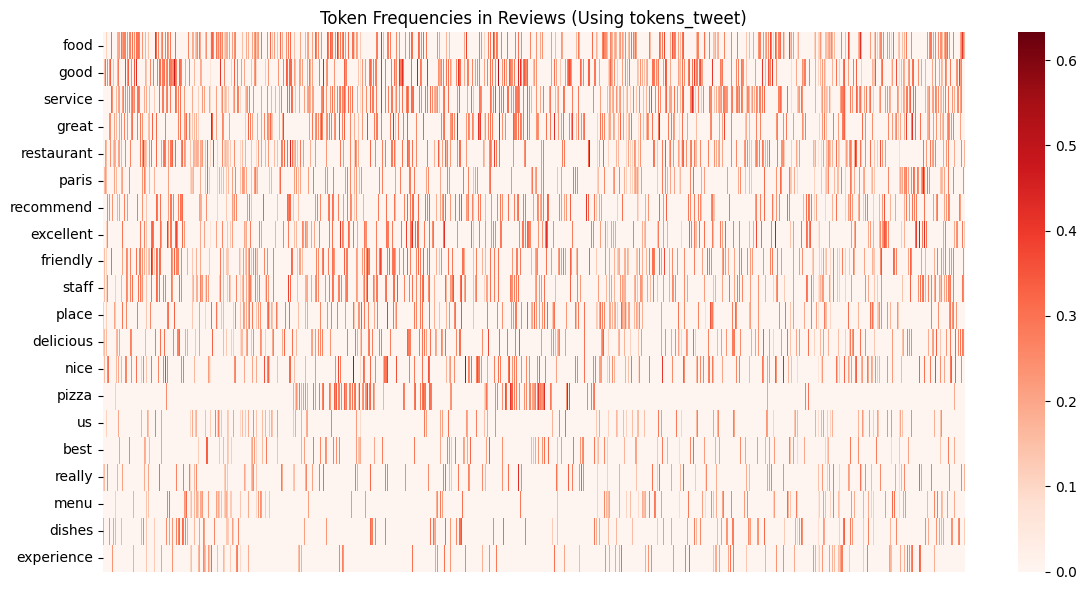

In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Get the most frequent tokens
all_tokens = [token for sublist in df['tokens_tweet'] for token in sublist]
token_counts = Counter(all_tokens)
top_tokens = [token for token, count in token_counts.most_common(20)]  # Get top 20 tokens


# 2. Create frequency dataframe (with dtype=float)
freq_df = pd.DataFrame(index=df.index, columns=top_tokens, dtype=float)
freq_df = freq_df.fillna(0)  # Initialize with 0s

# 3. Count token frequencies in tokens_tweet column
for index, row in df.iterrows():
    tokens = row['tokens_tweet']  # Get the list of tokens for the current row
    for token in tokens:
        if token in top_tokens:  # Only consider tokens in our top_tokens list
            freq_df.loc[index, token] += 1

# 4. Normalize frequencies by the number of tokens in the review
for index, row in df.iterrows():
    num_tokens = len(row['tokens_tweet'])
    freq_df.loc[index] = freq_df.loc[index] / num_tokens

# 5. Apply sqrt transformation for better visualization
freq_df = freq_df.apply(np.sqrt)

# 6. Create heatmap
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.heatmap(freq_df.T, cmap="Reds", xticklabels=False, yticklabels=True, cbar=True)
plt.title("Token Frequencies in Reviews (Using tokens_tweet)")
plt.tight_layout()
plt.show()

In [216]:
df.columns

Index(['restaurant_name', 'cust_name', 'rating', 'review_title', 'cust_type',
       'review_body', 'month_year', 'review_length', 'number_of_contributions',
       'num_tokens', 'tokens_tweet', 'tokens_title', 'sentiment',
       'review_body_text', 'review_title_text', 'body_sentiment',
       'title_sentiment', 'body_polarity', 'body_subjectivity',
       'title_polarity', 'title_subjectivity', 'body_bigrams', 'body_trigrams',
       'title_bigrams', 'title_trigrams', 'length_category',
       'review_body_tokens'],
      dtype='object')

In [217]:
df['tokens_tweet']

,tokens_tweet
1,"[make, pasted, copy, positive, reviews, provin..."
2,"[excellent, value, money, lunch, menu, weekday..."
3,"[excellent, experience, dinner, offered, many,..."
4,"[far, best, meal, paris, werent, sure, exactly..."
5,"[open, door, restaurantbistro, greeted, smile,..."
...,...
20290,"[family, dinner, recently, pleased, starters, ..."
20291,"[place, amazing, atmosphere, pleasant, staff, ..."
20292,"[partner, craving, indian, food, found, restau..."
20293,"[business, dinner, everything, perfect, best, ..."


In [218]:
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

# 1. Preprocessing (Using a custom analyzer for bigrams)

def bigram_analyzer(doc):
  """
  Custom analyzer function that returns the existing bigrams in the document.

  Args:
    doc: A list of bigrams (as in your 'body_bigrams' column).

  Returns:
    A list of bigrams (as strings).
  """
  return doc  # Simply return the existing bigrams

# Create CountVectorizer with the custom analyzer
vectorizer = CountVectorizer(
    analyzer=bigram_analyzer,
    max_df=0.95,
    min_df=2,
    #stop_words='english'  # Remove stop_words if needed
)

# Now, you can use the 'body_bigrams' column directly
dtm = vectorizer.fit_transform(df['body_bigrams'])

# 3. Apply LDA
num_topics = 5  # Choose the desired number of topics
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_topics = lda.fit_transform(dtm)
df['lda_topic'] = lda_topics.argmax(axis=1)

# 4. Apply NMF
nmf = NMF(n_components=num_topics, random_state=42)
nmf_topics = nmf.fit_transform(dtm)
df['nmf_topic'] = nmf_topics.argmax(axis=1)

# 5. Apply k-means Clustering
kmeans = KMeans(n_clusters=num_topics, random_state=42)
kmeans_clusters = kmeans.fit_predict(dtm)
df['kmeans_cluster'] = kmeans_clusters

# 6. Print Identified Topics
def print_topics(model, vectorizer, top_n=10):
    for i, topic in enumerate(model.components_):
        print(f"Topic {i}:")
        print([vectorizer.get_feature_names_out()[index] for index in topic.argsort()[-top_n:]])
        print("\n")

print("LDA Topics:")
print_topics(lda, vectorizer)

print("NMF Topics:")
print_topics(nmf, vectorizer)

<ipython-input-218-a79ef11ffba7>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lda_topic'] = lda_topics.argmax(axis=1)
<ipython-input-218-a79ef11ffba7>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['nmf_topic'] = nmf_topics.argmax(axis=1)
<ipython-input-218-a79ef11ffba7>:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

LDA Topics:
Topic 0:
['excellent service', 'highly recommended', 'best pizza', 'friendly staff', 'nice place', 'definitely come', 'quality products', 'warm welcome', 'highly recommend', 'come back']


Topic 1:
['food excellent', 'highly recommended', 'would definitely', 'one best', 'delicious food', 'quality food', 'friendly staff', 'food delicious', 'staff friendly', 'highly recommend']


Topic 2:
['great time', 'excellent service', 'food good', 'great experience', 'friendly staff', 'food great', 'come back', 'good food', 'great service', 'highly recommend']


Topic 3:
['really good', 'italian cuisine', 'good food', 'great time', 'tasting menu', 'italian restaurant', 'friendly staff', 'one best', 'highly recommended', 'highly recommend']


Topic 4:
['service good', 'best pizza', 'delicious food', 'one best', 'good value', 'good service', 'friendly service', 'highly recommended', 'value money', 'highly recommend']


NMF Topics:
Topic 0:
['food amazing', 'recommend anyone', 'staff highl

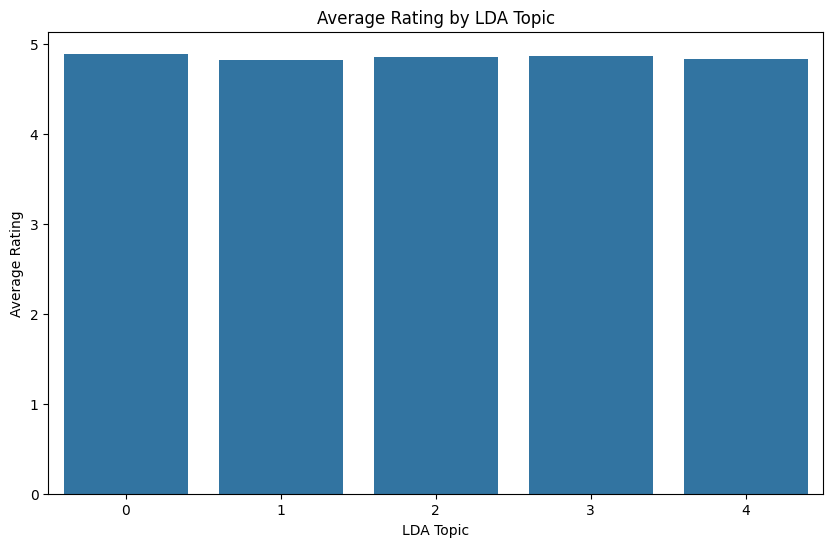

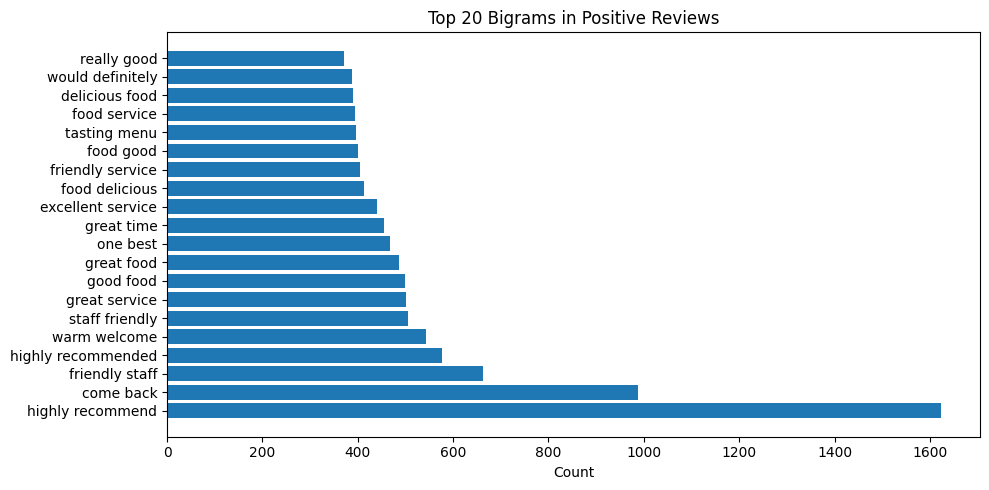

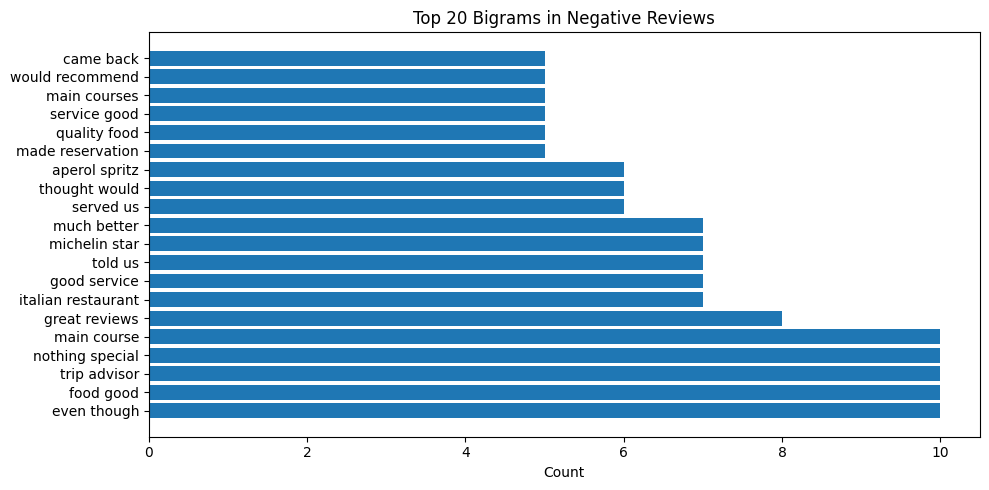

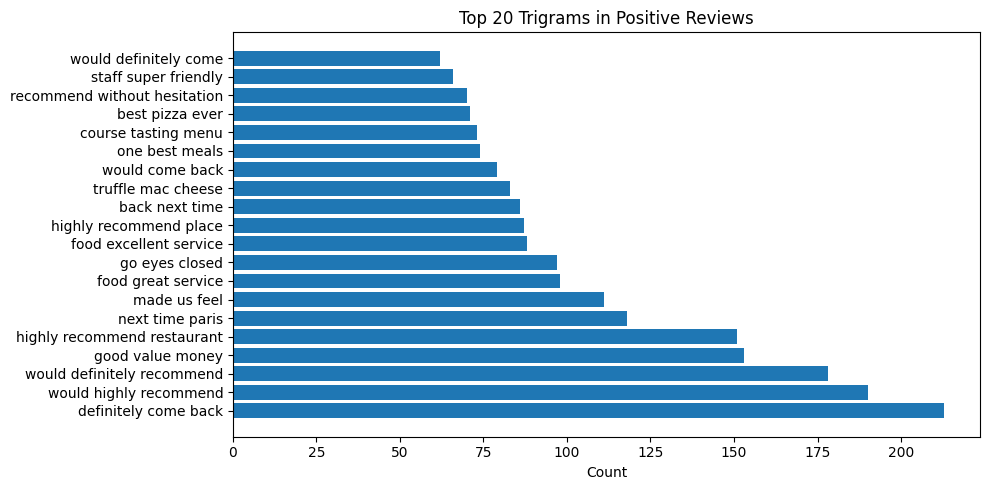

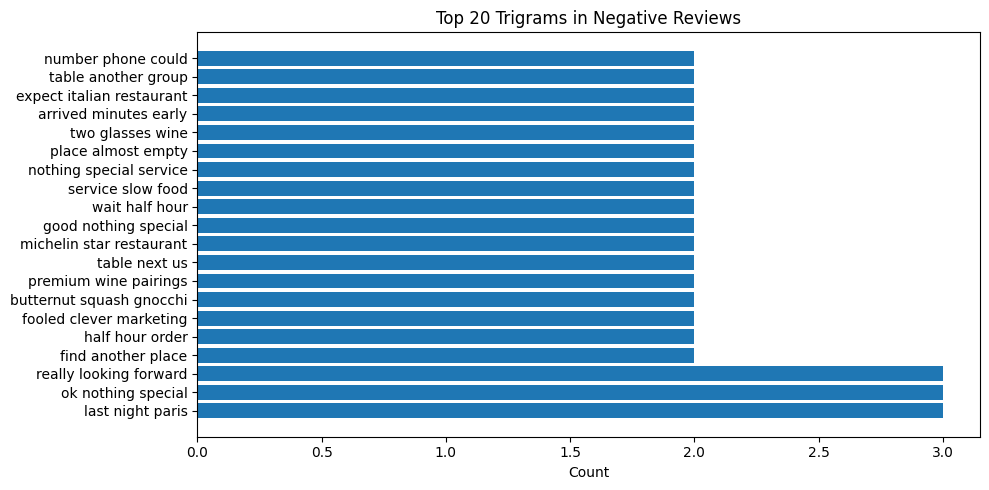

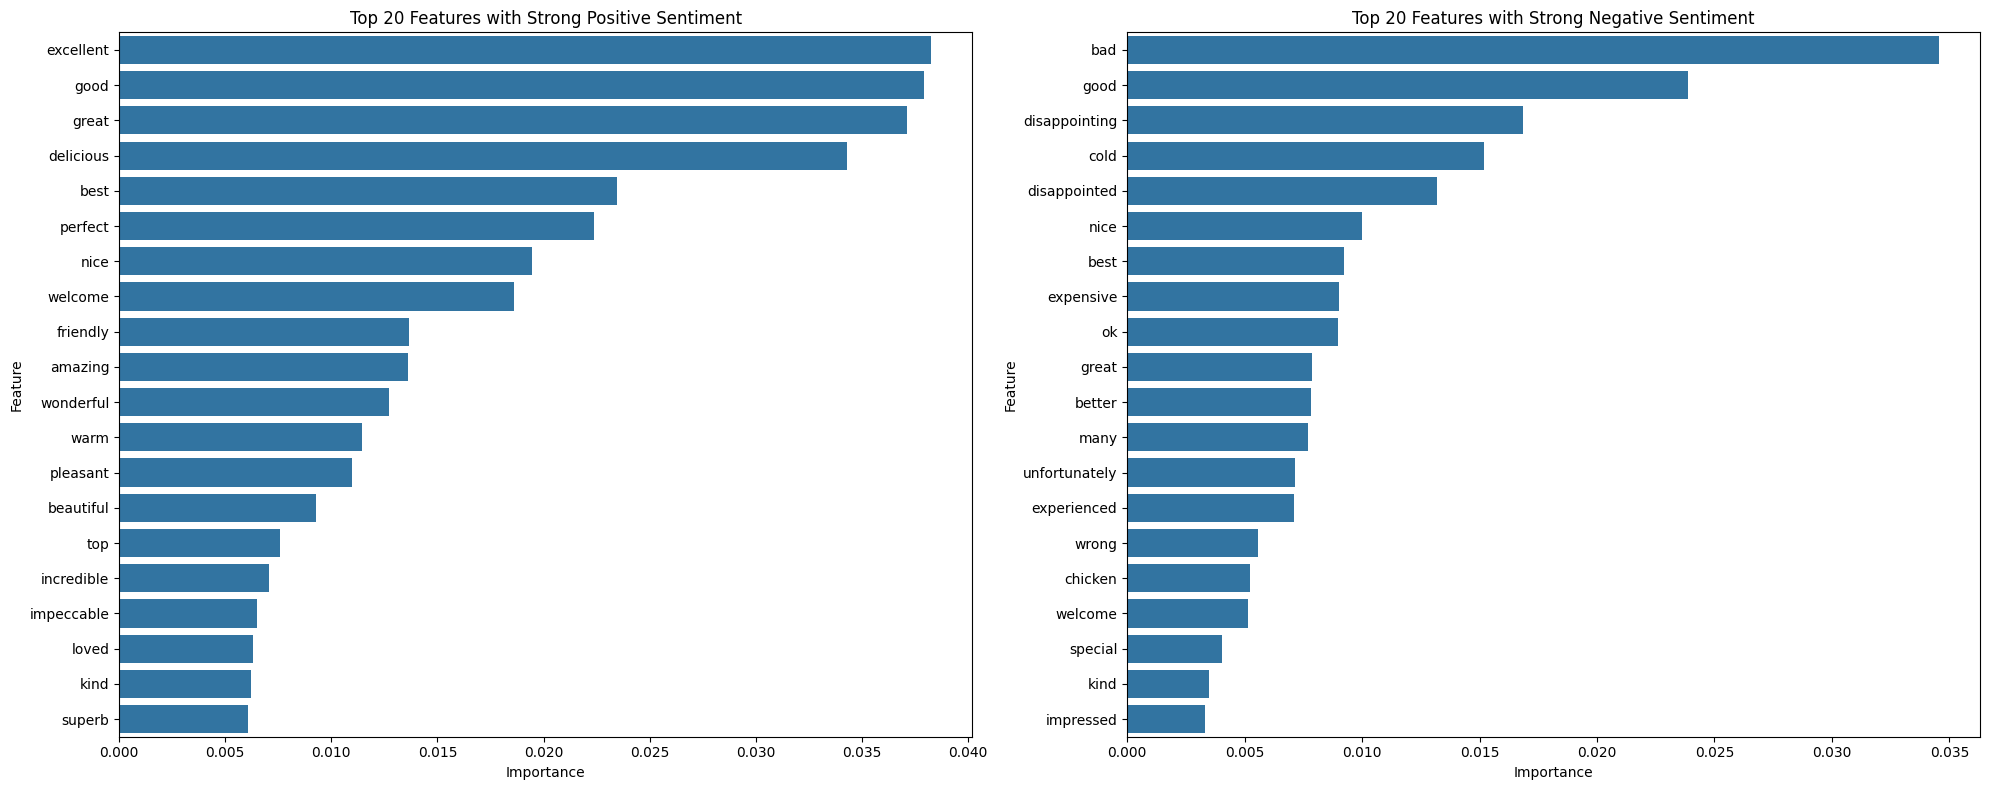

In [219]:
# Feature Importance Analysis

from collections import Counter
from textblob import TextBlob

# Plot average rating by LDA topic
topic_ratings = df.groupby('lda_topic')['rating'].mean()
plt.figure(figsize=(10, 6))
sns.barplot(x=topic_ratings.index, y=topic_ratings.values)
plt.title('Average Rating by LDA Topic')
plt.xlabel('LDA Topic')
plt.ylabel('Average Rating')
plt.show()

# Separate reviews by sentiment
positive_reviews = df[df['sentiment'] == 'Positive']
negative_reviews = df[df['sentiment'] == 'Negative']

# Get top bigrams for each sentiment
def get_top_bigrams(reviews, n=20):
    all_bigrams = []
    for bigrams in reviews['body_bigrams']:
        if isinstance(bigrams, list):
            all_bigrams.extend(bigrams)
    return Counter(all_bigrams).most_common(n)

# Get top bigrams
top_positive_bigrams = get_top_bigrams(positive_reviews)
top_negative_bigrams = get_top_bigrams(negative_reviews)

# Plot top bigrams for positive sentiment
plt.figure(figsize=(10, 5))
bigrams, counts = zip(*top_positive_bigrams)
plt.barh(range(len(counts)), counts)
plt.yticks(range(len(counts)), bigrams)
plt.title('Top 20 Bigrams in Positive Reviews')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Plot top bigrams for negative sentiment
plt.figure(figsize=(10, 5))
bigrams, counts = zip(*top_negative_bigrams)
plt.barh(range(len(counts)), counts)
plt.yticks(range(len(counts)), bigrams)
plt.title('Top 20 Bigrams in Negative Reviews')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Get top trigrams for each sentiment
def get_top_trigrams(reviews, n=20):
    all_trigrams = []
    for trigrams in reviews['body_trigrams']:
        if isinstance(trigrams, list):
            all_trigrams.extend(trigrams)
    return Counter(all_trigrams).most_common(n)

# Get top trigrams
top_positive_trigrams = get_top_trigrams(positive_reviews)
top_negative_trigrams = get_top_trigrams(negative_reviews)

# Plot top trigrams for positive sentiment
plt.figure(figsize=(10, 5))
trigrams, counts = zip(*top_positive_trigrams)
plt.barh(range(len(counts)), counts)
plt.yticks(range(len(counts)), trigrams)
plt.title('Top 20 Trigrams in Positive Reviews')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Plot top trigrams for negative sentiment
plt.figure(figsize=(10, 5))
trigrams, counts = zip(*top_negative_trigrams)
plt.barh(range(len(counts)), counts)
plt.yticks(range(len(counts)), trigrams)
plt.title('Top 20 Trigrams in Negative Reviews')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Feature importance analysis

# Calculate sentiment polarity for each word
def get_word_sentiment(word):
    return TextBlob(word).sentiment.polarity

# Create TF-IDF vectors with no stop words to capture all meaningful words
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['review_body_tokens'])
feature_names = tfidf.get_feature_names_out()

# Calculate sentiment scores for each word
word_sentiments = {word: get_word_sentiment(word) for word in feature_names}

# Get feature importance scores weighted by sentiment polarity
pos_importance = np.mean(X[df['sentiment']=='Positive'].toarray(), axis=0) * [abs(word_sentiments[word]) for word in feature_names]
neg_importance = np.mean(X[df['sentiment']=='Negative'].toarray(), axis=0) * [abs(word_sentiments[word]) for word in feature_names]

# Create DataFrames with feature importances
pos_features = pd.DataFrame({
    'Feature': feature_names,
    'Importance': pos_importance,
    'Sentiment': [word_sentiments[word] for word in feature_names]
}).sort_values('Importance', ascending=False)

neg_features = pd.DataFrame({
    'Feature': feature_names,
    'Importance': neg_importance,
    'Sentiment': [word_sentiments[word] for word in feature_names]
}).sort_values('Importance', ascending=False)

# Filter for words with strong sentiment (abs(sentiment) > 0.3)
pos_features = pos_features[abs(pos_features['Sentiment']) > 0.3].head(20)
neg_features = neg_features[abs(neg_features['Sentiment']) > 0.3].head(20)

# Plot feature importances
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=pos_features, x='Importance', y='Feature', ax=ax1)
ax1.set_title('Top 20 Features with Strong Positive Sentiment')

sns.barplot(data=neg_features, x='Importance', y='Feature', ax=ax2)
ax2.set_title('Top 20 Features with Strong Negative Sentiment')

plt.tight_layout()
plt.show()

In [223]:
# KWIC for top words and bigrams
from textacy.extract import keyword_in_context

def KWIC(*args, **kwargs):
    # call keyword_in_context with all params except 'print_only'
    return keyword_in_context(*args,
                       **{kw: arg for kw, arg in kwargs.items()
                        if kw != 'print_only'})

keywords = ['excellent', 'bad', 'even though', 'highly recommend']

for keyword in keywords:
    print(f"\nKWIC examples for '{keyword}':")
    kwic_list = []
    for tokens in df['tokens_tweet']:
        if isinstance(tokens, list):
            try:
                text = " ".join(tokens)
                contexts = KWIC(text, keyword, ignore_case=True, window_width=35)
                if contexts:
                    kwic_list.extend(contexts)
            except:
                continue
    # Print up to 5 KWIC examples for the current keyword
    for context in kwic_list[:5]:
        print(f"...{context[0]} {context[1]} {context[2]}...")


KWIC examples for 'excellent':
... excellent  value money lunch menu weekdays ca...
...e evening event leave menu happens  excellent  value money...
... excellent  experience dinner offered many opt...
...fast service friendly staff really  excellent  food pricequality ratio correct ea...
... night place good plentiful dishes  excellent  tartare forgotten bring us starter...

KWIC examples for 'bad':
...french exiled land  bad  food looking restaurant would keep...
...esides waitresses waiters charming  bad  cafe closed monday tuesday...
...e dry desserts nothing crazy taste  bad  especially dishes far given rating...
...obviously understand never treated  bad ly restaurant like city world fortu...
...ne person short tourist trap avoid  bad  impossible reach evidence...

KWIC examples for 'even though':
...nt there's nothing good real fries  even though  seems simple spouse enjoyed chicke...
...rrived around owner found us table  even though  restaurant full milanese escalope ...
...d

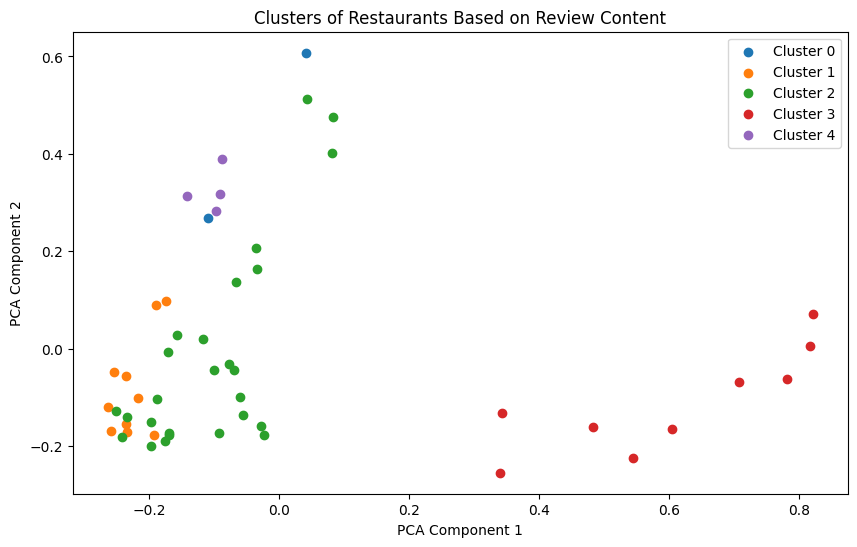


Top keywords per cluster:

Cluster 0:
indian, food, service, restaurant, good, great, really, excellent, place, delicious


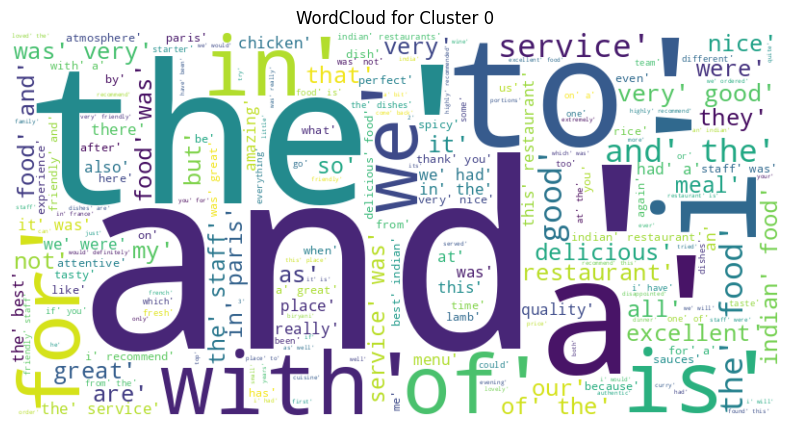


Cluster 1:
service, food, restaurant, good, great, menu, dishes, wine, experience, excellent


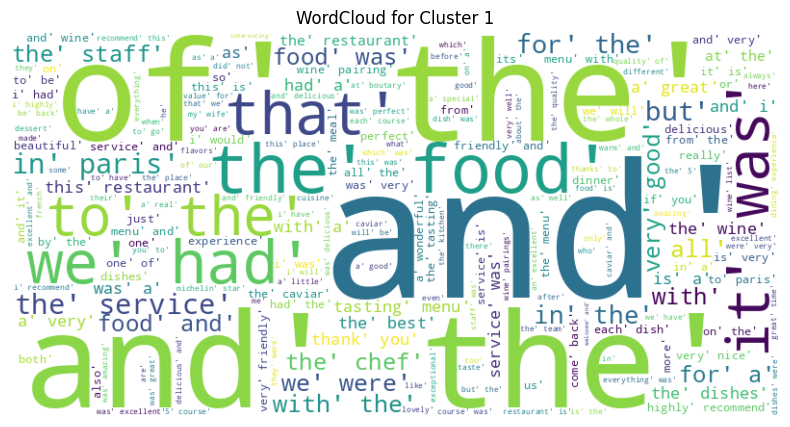


Cluster 2:
good, food, great, service, restaurant, place, paris, friendly, recommend, delicious


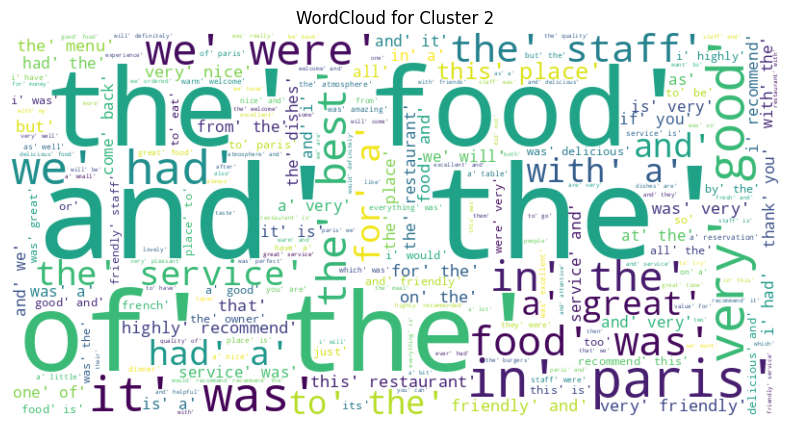


Cluster 3:
pizza, pizzas, good, service, recommend, italian, restaurant, excellent, great, place


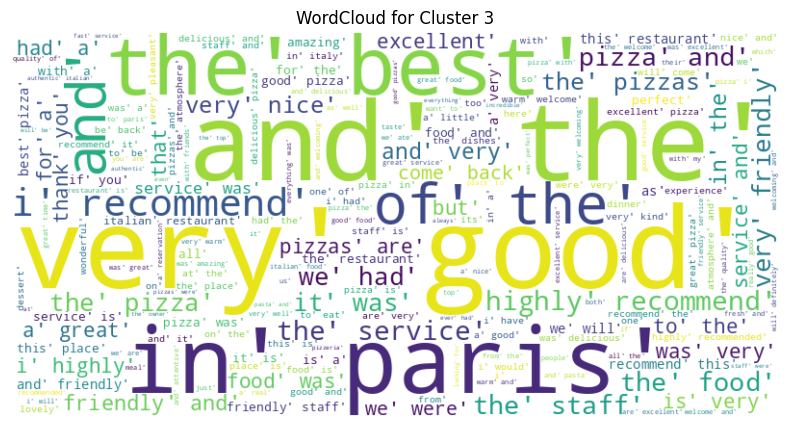


Cluster 4:
lebanese, food, restaurant, clara, service, good, great, issa, delicious, excellent


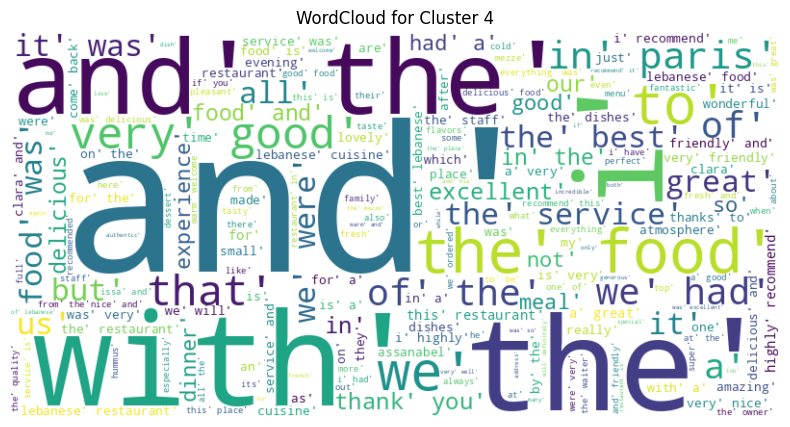

In [120]:
# Imports

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Aggregate Reviews by Restaurant
df_grouped = df.groupby('restaurant_name')['tokens_tweet'].apply(lambda x: ' '.join(str(i) for i in x if not pd.isnull(i).any())).reset_index()
# 2. Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df_grouped['tokens_tweet'])

# 3. Reduce dimensions (PCA for visualization)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

# 4. Clustering (K-Means)
# Optional: You can use Elbow Method or Silhouette Score to choose best K
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df_grouped['Cluster'] = kmeans.fit_predict(X)

# 5. Visualization
plt.figure(figsize=(10, 6))
for cluster in range(k):
    plt.scatter(
        X_pca[df_grouped['Cluster'] == cluster, 0],
        X_pca[df_grouped['Cluster'] == cluster, 1],
        label=f'Cluster {cluster}'
    )
plt.legend()
plt.title('Clusters of Restaurants Based on Review Content')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

# 6. Analyze key terms per cluster
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

print("\nTop keywords per cluster:")
for i in range(k):
    print(f"\nCluster {i}:")
    keywords = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(keywords))

    # Optional: WordCloud for each cluster
    cluster_text = ' '.join(df_grouped[df_grouped['Cluster'] == i]['tokens_tweet'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(cluster_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud for Cluster {i}')
    plt.show()

SuperVised Learning:

In [94]:
df.columns

Index(['restaurant_name', 'cust_name', 'rating', 'review_title', 'cust_type',
       'review_body', 'month_year', 'review_length', 'number_of_contributions',
       'num_tokens', 'tokens_tweet', 'tokens_title', 'sentiment',
       'review_body_text', 'review_title_text', 'body_sentiment',
       'title_sentiment', 'body_polarity', 'body_subjectivity',
       'title_polarity', 'title_subjectivity', 'body_bigrams', 'body_trigrams',
       'title_bigrams', 'title_trigrams', 'length_category',
       'review_body_tokens', 'lda_topic', 'nmf_topic', 'kmeans_cluster'],
      dtype='object')

In [95]:
# Function to join tokens back into a string
def join_tokens(tokens):
    # Handle empty tokens to avoid errors
    if isinstance(tokens, list):
        return " ".join(tokens)
    else:
        return ""

# Apply the function to create review_body_tokens and review_title_tokens columns
df['review_body_tokens'] = df['tokens_tweet'].apply(join_tokens)
df['review_title_tokens'] = df['tokens_title'].apply(join_tokens)


<ipython-input-95-5c63c98dcd76>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_body_tokens'] = df['tokens_tweet'].apply(join_tokens)
<ipython-input-95-5c63c98dcd76>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_title_tokens'] = df['tokens_title'].apply(join_tokens)


In [104]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer  # Import SimpleImputer

# 1. Data Preparation
# Ensure 'review_body_tokens' and 'review_title_tokens' are strings
df['review_body_tokens'] = df['review_body_tokens'].astype(str)
df['review_title_tokens'] = df['review_title_tokens'].astype(str)

X = df[['review_body_tokens', 'review_title_tokens', 'number_of_contributions', 'review_length', 'body_polarity', 'body_subjectivity', 'title_polarity', 'title_subjectivity']]  # Removed 'restaurant_name'
y = df['sentiment']  # Target variable: sentiment

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# 2. Feature Engineering and Preprocessing
# Combine text columns into a single feature
X_train['combined_text'] = X_train['review_body_tokens'] + ' ' + X_train['review_title_tokens']
X_val['combined_text'] = X_val['review_body_tokens'] + ' ' + X_val['review_title_tokens']
X_test['combined_text'] = X_test['review_body_tokens'] + ' ' + X_test['review_title_tokens']

# Define preprocessing steps for different feature types
# Removed OneHotEncoder for 'restaurant_name'
# Added SimpleImputer to handle NaN values in numerical features
# Changed StandardScaler to MinMaxScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english'), 'combined_text'),  # Apply to the combined text column
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with the mean
            ('scaler', MinMaxScaler()),  # Use MinMaxScaler to scale features between 0 and 1
        ]), ['number_of_contributions', 'review_length', 'body_polarity', 'body_subjectivity', 'title_polarity', 'title_subjectivity']),
    ])

# 3. Model Selection and Hyperparameter Tuning

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),  # Increased max_iter
    'Support Vector Machine': SVC(random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

param_grids = {
    'Logistic Regression': {'classifier__C': [0.1, 1, 10]},
    'Support Vector Machine': {'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['linear', 'rbf']},
    'Naive Bayes': {'classifier__alpha': [0.1, 1, 10]},
    'Random Forest': {'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [None, 5, 10]},
    'Gradient Boosting': {'classifier__n_estimators': [100, 200, 300], 'classifier__learning_rate': [0.01, 0.1, 1]}
}

best_models = {}
for model_name, model in models.items():
    print(f"Tuning {model_name}...")
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    grid_search = GridSearchCV(pipeline, param_grids[model_name], cv=5, scoring='accuracy')

    # The change is here: Fit the entire pipeline, not just the vectorizer
    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_
    print(f"Best Hyperparameters for {model_name}: {grid_search.best_params_}\n")

# 4. Model Evaluation and Selection

results = []
for model_name, model in best_models.items():
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, pos_label='Positive')
    recall = recall_score(y_val, y_pred, pos_label='Positive')
    f1 = f1_score(y_val, y_pred, pos_label='Positive')
    results.append([model_name, accuracy, precision, recall, f1])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\nModel Evaluation Results on Validation Set:")
print(results_df)

# Select the best model based on validation results
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_model = best_models[best_model_name]

# Final Evaluation on Test Set
y_pred_test = best_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, pos_label='Positive')
recall_test = recall_score(y_test, y_pred_test, pos_label='Positive')
f1_test = f1_score(y_test, y_pred_test, pos_label='Positive')

print(f"\nBest Model: {best_model_name}")
print(f"Accuracy on Test Set: {accuracy_test:.4f}")
print(f"Precision on Test Set: {precision_test:.4f}")
print(f"Recall on Test Set: {recall_test:.4f}")
print(f"F1-Score on Test Set: {f1_test:.4f}")

<ipython-input-104-2f25808435bb>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_body_tokens'] = df['review_body_tokens'].astype(str)
<ipython-input-104-2f25808435bb>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_title_tokens'] = df['review_title_tokens'].astype(str)


Tuning Logistic Regression...
Best Hyperparameters for Logistic Regression: {'classifier__C': 10}

Tuning Support Vector Machine...
Best Hyperparameters for Support Vector Machine: {'classifier__C': 10, 'classifier__kernel': 'rbf'}

Tuning Naive Bayes...
Best Hyperparameters for Naive Bayes: {'classifier__alpha': 1}

Tuning Random Forest...
Best Hyperparameters for Random Forest: {'classifier__max_depth': None, 'classifier__n_estimators': 100}

Tuning Gradient Boosting...
Best Hyperparameters for Gradient Boosting: {'classifier__learning_rate': 0.01, 'classifier__n_estimators': 300}


Model Evaluation Results on Validation Set:
                    Model  Accuracy  Precision    Recall  F1-Score
0     Logistic Regression  0.990231   0.992131  0.998021  0.995067
1  Support Vector Machine  0.992836   0.994091  0.998681  0.996380
2             Naive Bayes  0.987301   0.987301  1.000000  0.993610
3           Random Forest  0.988603   0.988588  1.000000  0.994261
4       Gradient Boosting  0.